In [5]:
from popsborder.scenarios import run_scenarios
from popsborder.inputs import load_configuration, load_scenario_table
from popsborder.outputs import save_scenario_result_to_pandas

In [6]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [7]:
from pathlib import Path
datadir = Path("data")
basic_config = load_configuration(datadir / "base_config.yml")
scenario_table = load_scenario_table(datadir / "scenarios_long.csv")

In [8]:
results = run_scenarios(
    config=basic_config,
    scenario_table=scenario_table,
    seed=42,
    num_simulations=2,
    num_consignments=10,
)

Running scenario: clustered_10
Running scenario: clustered_12
Running scenario: clustered_14
Running scenario: clustered_16
Running scenario: clustered_09
Running scenario: clustered_11
Running scenario: clustered_13
Running scenario: clustered_15
Running scenario: clustered_02
Running scenario: clustered_04
Running scenario: clustered_06
Running scenario: clustered_08
Running scenario: clustered_01
Running scenario: clustered_03
Running scenario: clustered_05
Running scenario: clustered_07
Running scenario: clustered_35
Running scenario: clustered_36
Running scenario: clustered_39
Running scenario: clustered_40
Running scenario: clustered_43
Running scenario: clustered_44
Running scenario: clustered_47
Running scenario: clustered_48
Running scenario: clustered_34
Running scenario: clustered_38
Running scenario: clustered_42
Running scenario: clustered_46
Running scenario: clustered_33
Running scenario: clustered_37
Running scenario: clustered_41
Running scenario: clustered_45
Running 

In [9]:
df = save_scenario_result_to_pandas(
    results,
    config_columns=[
        "name",
        "consignment_name",
        "inspection_name",
        "consignment/parameter_based/boxes/min",
        "consignment/parameter_based/boxes/max",
        "consignment/items_per_box/default",
        "contamination/contamination_rate/parameters",
        "contamination/arrangement",
        "inspection/unit",
        "inspection/sample_strategy",
        "inspection/proportion/value",
        "inspection/hypergeometric/detection_level",
        "inspection/selection_strategy",
        "inspection/within_box_pct",
        "inspection/cluster/cluster_selection",
    ],
    result_columns=[
        "missing",
        "true_contamination_rate",
        "max_missed_contamination_rate",
        "avg_missed_contamination_rate",
        "max_intercepted_contamination_rate",
        "avg_intercepted_contamination_rate",
        "avg_boxes_opened_completion",
        "avg_boxes_opened_detection",
        "avg_items_inspected_completion",
        "avg_items_inspected_detection",
        "pct_items_inspected_detection",
        "pct_contaminant_unreported_if_detection",
    ],
)

In [10]:
df['consignment_name'] = pd.Categorical(df['consignment_name'])
consignment_order = ["contamination_5", "contamination_10", "contamination_25", "small", "large", "maritime", "clustered", "clustered_small", "clustered_large"]
df['consignment_name'] = df['consignment_name'].cat.reorder_categories(consignment_order, ordered=True)
df

,name,consignment_name,inspection_name,consignment/parameter_based/boxes/min,consignment/parameter_based/boxes/max,consignment/items_per_box/default,contamination/contamination_rate/parameters,contamination/arrangement,inspection/unit,inspection/sample_strategy,...,max_missed_contamination_rate,avg_missed_contamination_rate,max_intercepted_contamination_rate,avg_intercepted_contamination_rate,avg_boxes_opened_completion,avg_boxes_opened_detection,avg_items_inspected_completion,avg_items_inspected_detection,pct_items_inspected_detection,pct_contaminant_unreported_if_detection
0,clustered_10,clustered,boxes 0.01 hypergeometric random,5,25,200,"[1, 80]",clustered,box,hypergeometric,...,NaN,NaN,0.018064,0.007532,13.40,2.00,2680.0,400.00,14.058645,0.000000
1,clustered_12,clustered,boxes 0.05 hypergeometric random,5,25,200,"[1, 80]",clustered,box,hypergeometric,...,NaN,NaN,0.018129,0.007516,13.55,1.95,2710.0,390.00,13.275576,0.000000
2,clustered_14,clustered,boxes 0.1 hypergeometric random,5,25,200,"[1, 80]",clustered,box,hypergeometric,...,0.009571,0.008613,0.018229,0.007348,11.70,3.55,2340.0,710.00,26.396262,0.000000
3,clustered_16,clustered,boxes 0.25 hypergeometric random,5,25,200,"[1, 80]",clustered,box,hypergeometric,...,0.018125,0.008441,0.013309,0.007056,7.70,5.00,1540.0,1000.00,33.991995,0.000000
4,clustered_09,clustered,boxes 0.01 hypergeometric convenience,5,25,200,"[1, 80]",clustered,box,hypergeometric,...,NaN,NaN,0.018105,0.007519,12.85,1.35,2570.0,270.00,10.456804,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,small_30,small,items 25% random,1,3,200,"[1, 80]",random,item,proportion,...,0.030000,0.010301,NaN,NaN,2.20,2.20,8.8,8.80,2.000000,0.000000
428,small_17,small,items 2% convenience,1,3,200,"[1, 80]",random,item,proportion,...,0.034167,0.017326,0.042500,0.020417,1.00,1.00,7.2,4.85,1.344427,66.746411
429,small_21,small,items 5% convenience,1,3,200,"[1, 80]",random,item,proportion,...,0.034167,0.017326,0.042500,0.020417,1.00,1.00,7.2,4.85,1.344427,66.746411
430,small_25,small,items 10% convenience,1,3,200,"[1, 80]",random,item,proportion,...,0.034167,0.017326,0.042500,0.020417,1.00,1.00,7.2,4.85,1.344427,66.746411


<Axes: xlabel='inspection_name'>

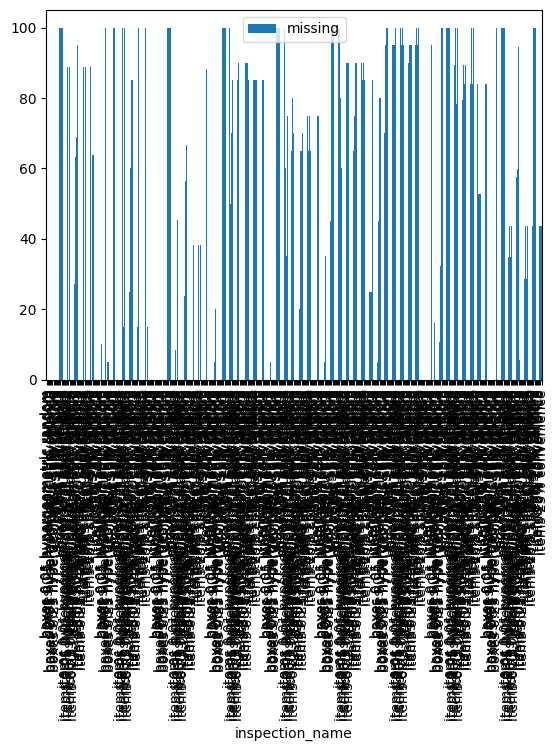

In [11]:
df.plot(kind="bar", x="inspection_name", y="missing")

In [12]:
#df["consignment"] = df.apply(lambda row: re.sub("_[0-9]+$", "", row["name"]), axis = 1)

C:\Users\ling1\AppData\Local\Temp\ipykernel_34220\3638466821.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("consignment_name").agg({"missing": "mean"}).reset_index().plot(kind="bar", x="consignment_name", y="missing")


<Axes: xlabel='consignment_name'>

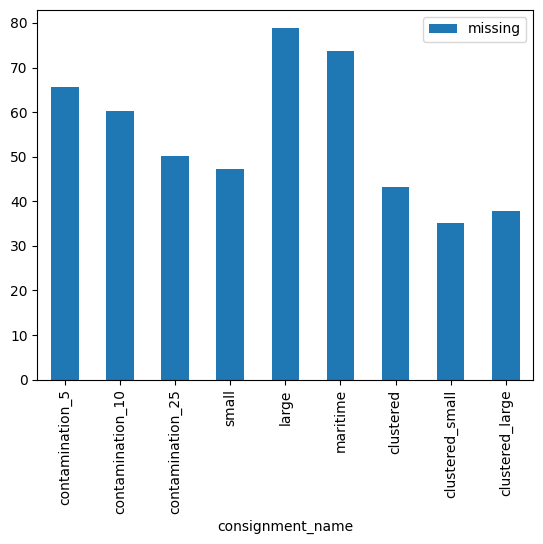

In [13]:
df.groupby("consignment_name").agg({"missing": "mean"}).reset_index().plot(kind="bar", x="consignment_name", y="missing")

Text(0.5, 1.0, 'Avg percent contaminated consignments missed by inspection')

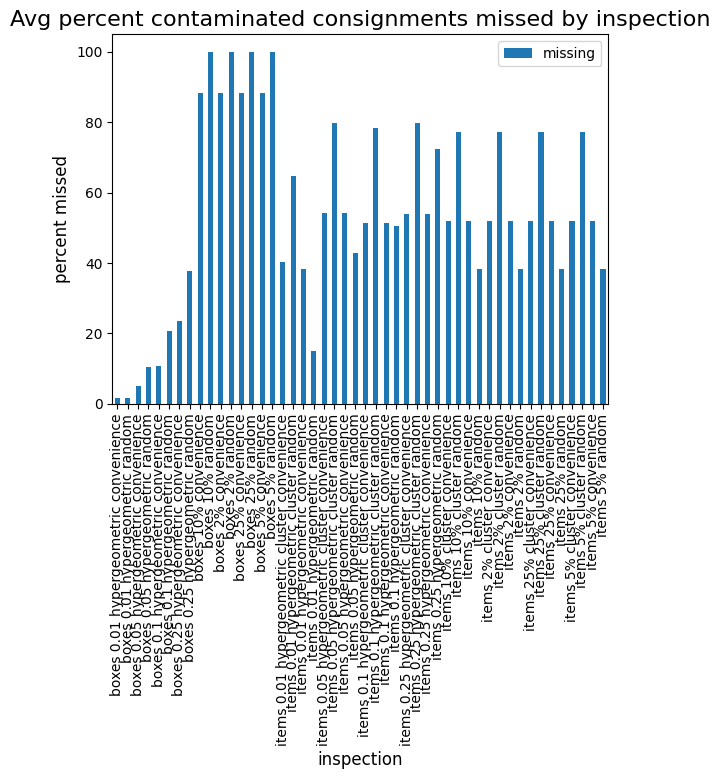

In [14]:
df.groupby("inspection_name").agg({"missing": "mean"}).reset_index().plot(kind="bar", x="inspection_name", y="missing")
plt.xlabel("inspection", size=12)
plt.ylabel("percent missed", size=12)
plt.title("Avg percent contaminated consignments missed by inspection", size=16)

In [15]:
inspections_vs_consignments = df.pivot_table(index=["inspection_name"], columns=["consignment_name"], values=["missing"])
inspections_vs_consignments

C:\Users\ling1\AppData\Local\Temp\ipykernel_34220\1623704985.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  inspections_vs_consignments = df.pivot_table(index=["inspection_name"], columns=["consignment_name"], values=["missing"])


missing  \
consignment_name                              contamination_5   
inspection_name                                                 
boxes 0.01 hypergeometric convenience                     0.0   
boxes 0.01 hypergeometric random                          0.0   
boxes 0.05 hypergeometric convenience                     0.0   
boxes 0.05 hypergeometric random                          0.0   
boxes 0.1 hypergeometric convenience                     10.0   
boxes 0.1 hypergeometric random                           5.0   
boxes 0.25 hypergeometric convenience                    45.0   
boxes 0.25 hypergeometric random                         35.0   
boxes 10% convenience                                   100.0   
boxes 10% random                                        100.0   
boxes 2% convenience                                    100.0   
boxes 2% random                                         100.0   
boxes 25% convenience                                   100.0   
boxes 25% random                                        100.0   
boxes 5% convenience                                    100.0   
boxes 5% random                                         100.0   
items 0.01 hypergeometric cluster convenience            60.0   
items 0.01 hypergeometric cluster random                 80.0   
items 0.01 hypergeometric convenience                    75.0   
items 0.01 hypergeometric random                          0.0   
items 0.05 hypergeometric cluster convenience            90.0   
items 0.05 hypergeometric cluster random                 90.0   
items 0.05 hypergeometric convenience                    90.0   
items 0.05 hypergeometric random                         10.0   
items 0.1 hypergeometric cluster convenience             90.0   
items 0.1 hypergeometric cluster random                  90.0   
items 0.1 hypergeometric convenience                     90.0   
items 0.1 hypergeometric random                          10.0   
items 0.25 hypergeometric cluster convenience            90.0   
items 0.25 hypergeometric cluster random                 90.0   
items 0.25 hypergeometric convenience                    90.0   
items 0.25 hypergeometric random                         65.0   
items 10% cluster convenience                            85.0   
items 10% cluster random                                 90.0   
items 10% convenience                                    85.0   
items 10% random                                         25.0   
items 2% cluster convenience                             85.0   
items 2% cluster random                                  90.0   
items 2% convenience                                     85.0   
items 2% random                                          25.0   
items 25% cluster convenience                            85.0   
items 25% cluster random                                 90.0   
items 25% convenience                                    85.0   
items 25% random                                         25.0   
items 5% cluster convenience                             85.0   
items 5% cluster random                                  90.0   
items 5% convenience                                     85.0   
items 5% random                                          25.0   

                                                                \
consignment_name                              contamination_10   
inspection_name                                                  
boxes 0.01 hypergeometric convenience                      0.0   
boxes 0.01 hypergeometric random                           0.0   
boxes 0.05 hypergeometric convenience                      0.0   
boxes 0.05 hypergeometric random                           0.0   
boxes 0.1 hypergeometric convenience                       0.0   
boxes 0.1 hypergeometric random                            5.0   
boxes 0.25 hypergeometric convenience                     35.0   
boxes 0.25 hypergeometric random                          20.0   
boxes 10% co

<Axes: xlabel='inspection_name'>

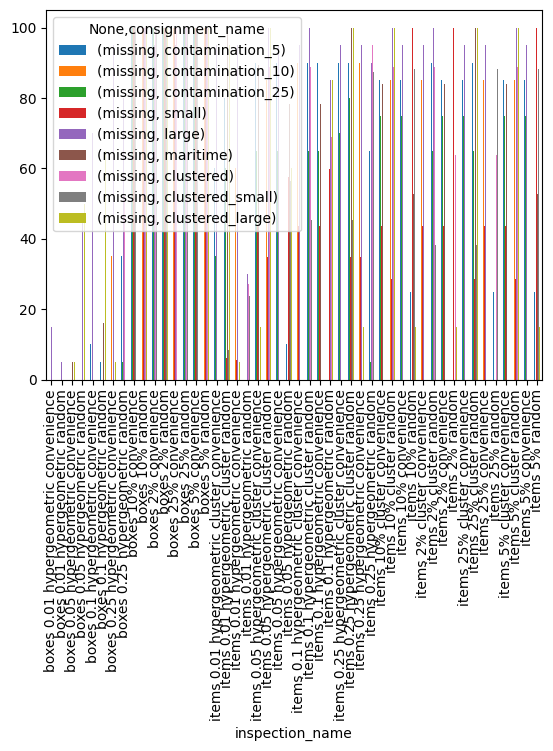

In [16]:
inspections_vs_consignments.plot(kind="bar")

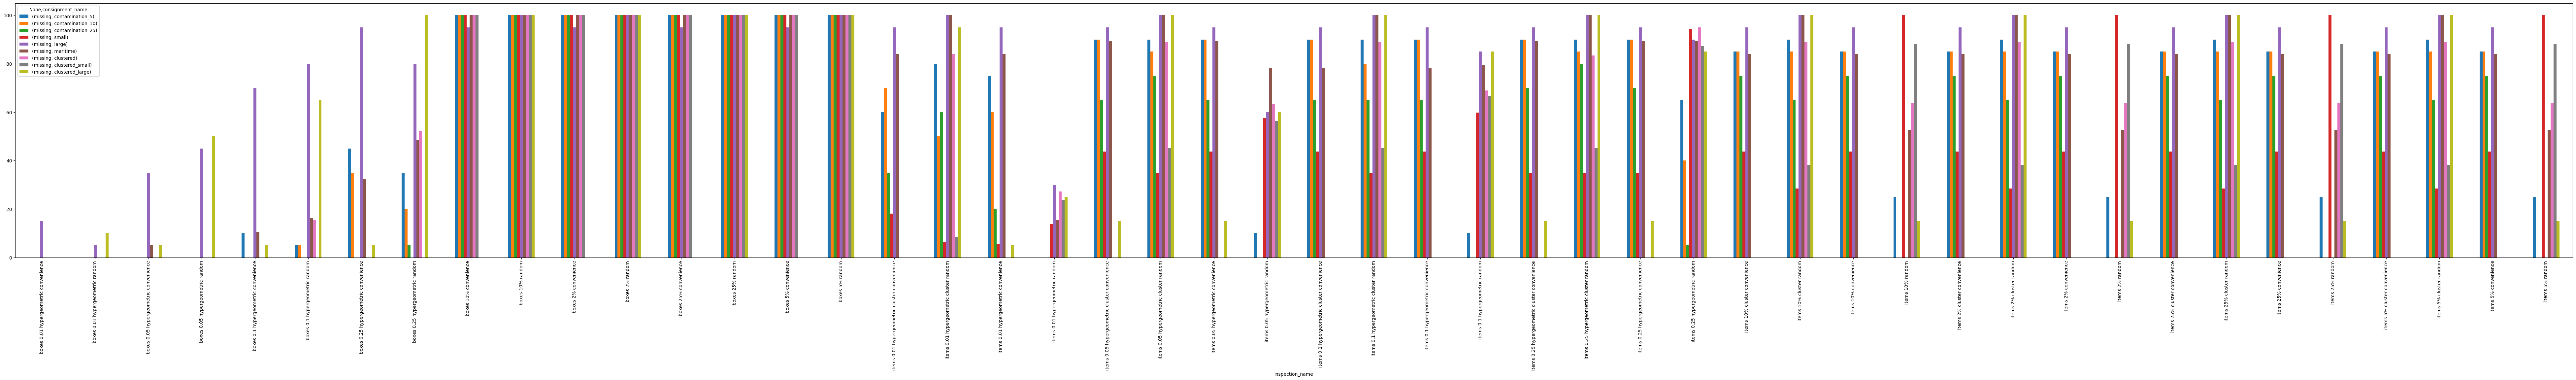

In [17]:
ax = inspections_vs_consignments.plot(kind="bar", figsize=(100, 10))
#ax.figure.savefig("inspections_vs_consignments_bar.png")

In [18]:
from itertools import cycle, islice

it = cycle(list(range(1,49)))
df['inspection_num'] = list(islice(it, len(df)))

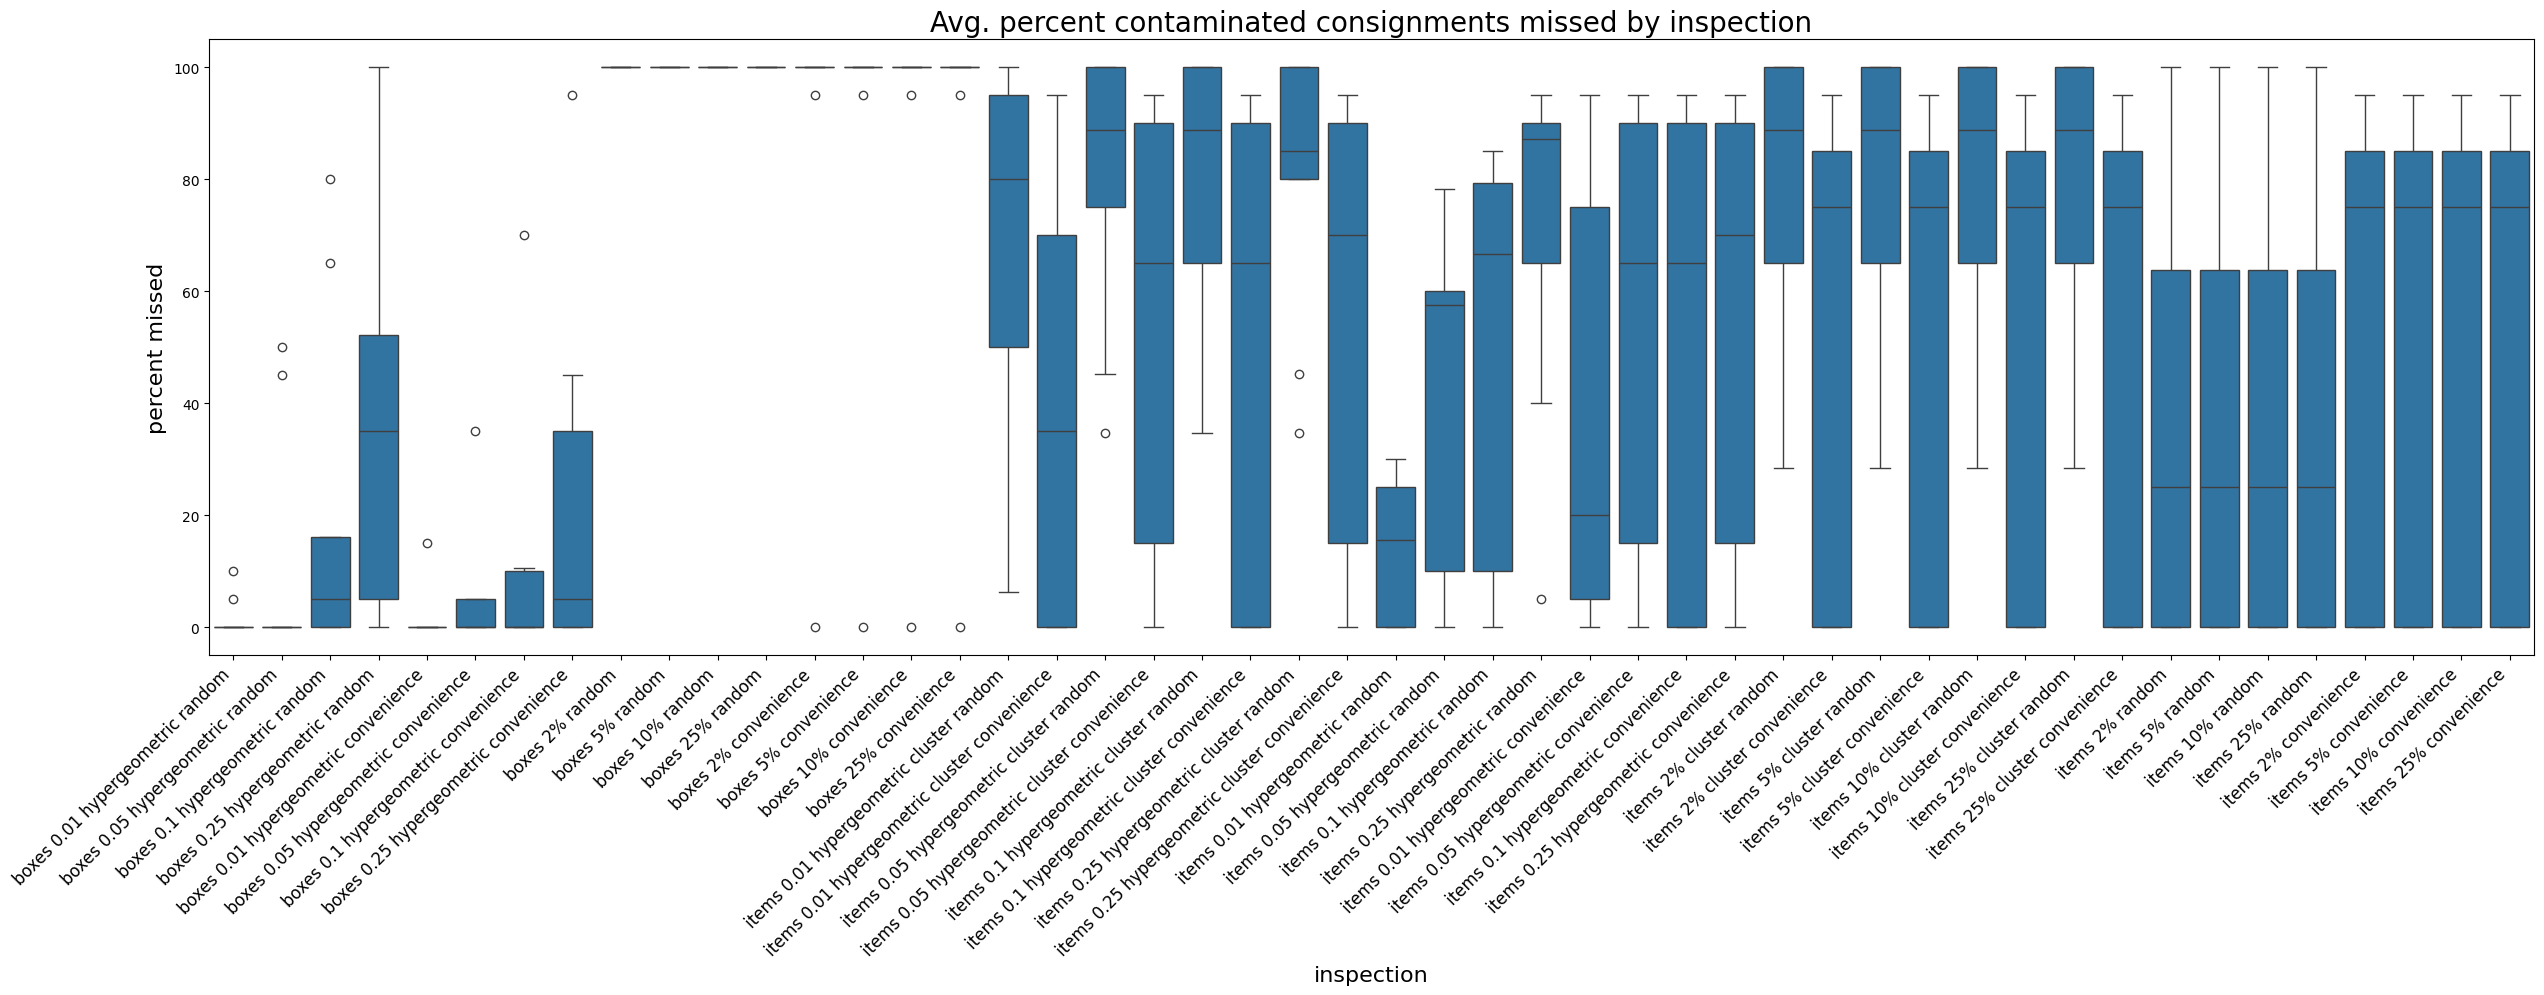

In [19]:
plt.figure(figsize=(30, 8))
sns.boxplot(x="inspection_name", y="missing", data=df)
plt.xticks(
    rotation=45, 
    horizontalalignment='right',
    fontweight='light',
    fontsize='large'  
)
plt.xlabel("inspection", size=16)
plt.ylabel("percent missed", size=16)
plt.title("Avg. percent contaminated consignments missed by inspection", size=20)
plt.savefig("missed_by_inspection_boxplot.png", bbox_inches = "tight")

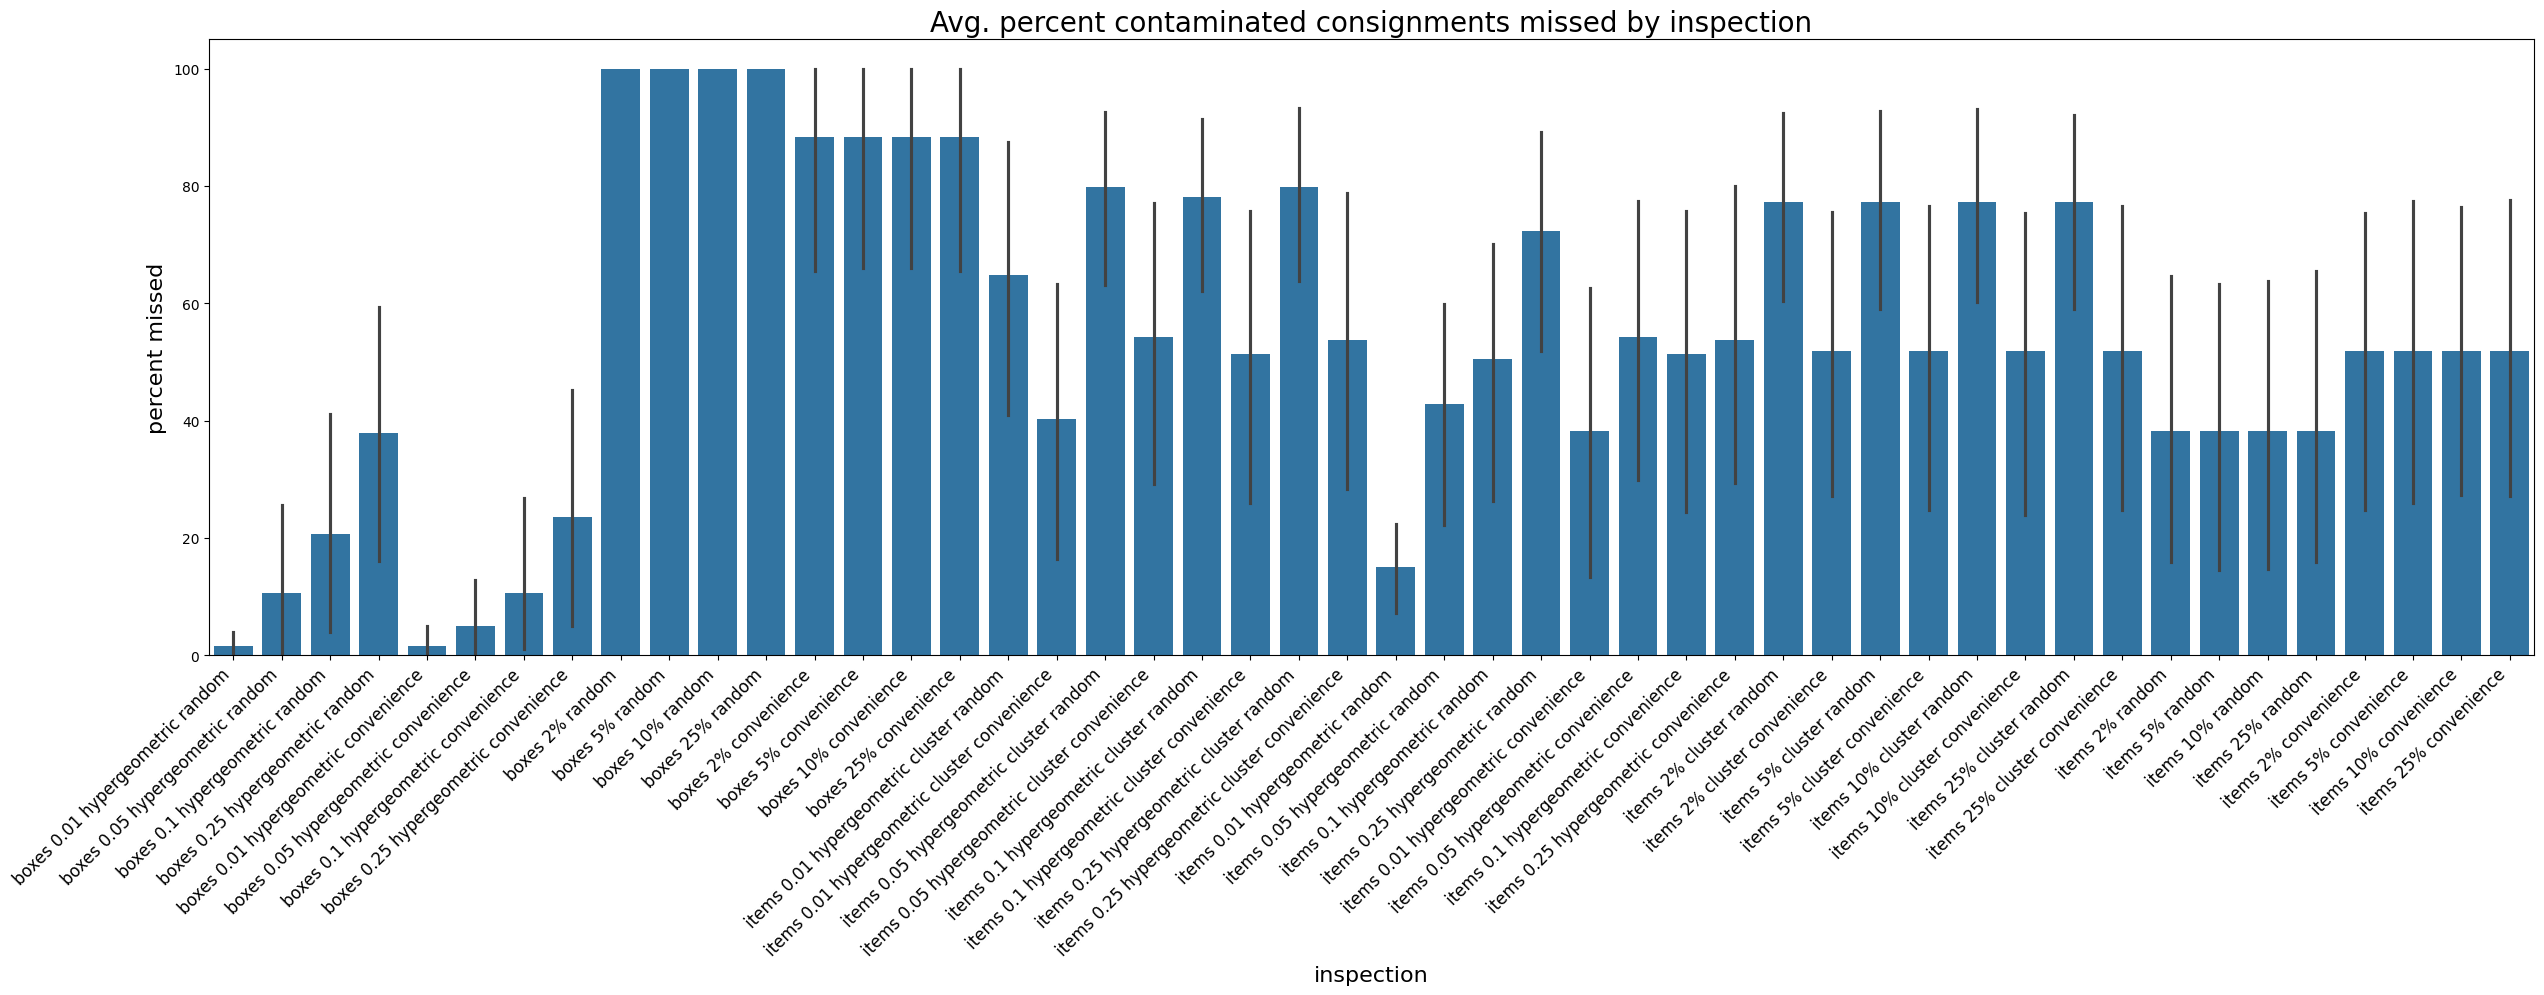

In [20]:
plt.figure(figsize=(30, 8))
sns.barplot(x="inspection_name", y="missing", data=df)
plt.xticks(
    rotation=45, 
    horizontalalignment='right',
    fontweight='light',
    fontsize='large'  
)
plt.xlabel("inspection", size=16)
plt.ylabel("percent missed", size=16)
plt.title("Avg. percent contaminated consignments missed by inspection", size=20)
plt.savefig("missed_by_inspection.png", bbox_inches = "tight")

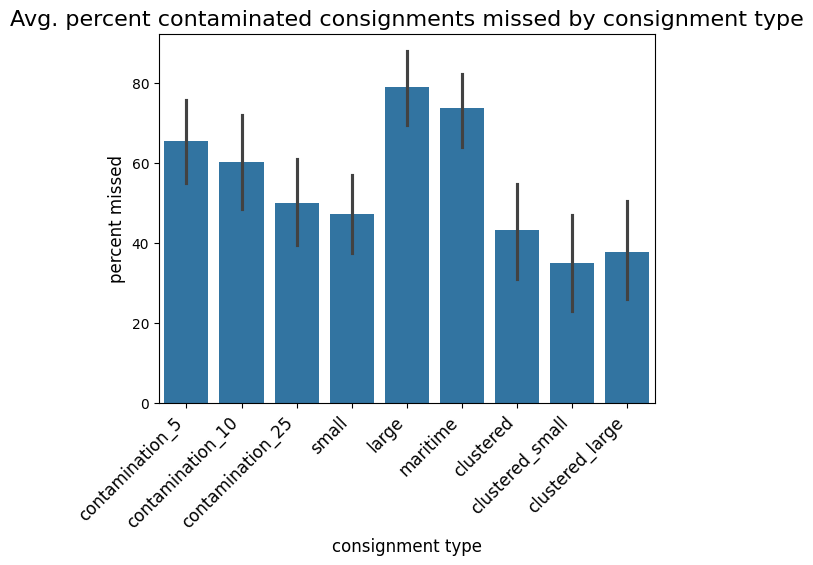

In [21]:
sns.barplot(x="consignment_name", y="missing", data=df)
plt.xticks(
    rotation=45, 
    horizontalalignment='right',
    fontweight='light',
    fontsize='large'  
)
plt.xlabel("consignment type", size=12)
plt.ylabel("percent missed", size=12)
plt.title("Avg. percent contaminated consignments missed by consignment type", size=16)
plt.savefig("missed_by_consignment.png", bbox_inches = "tight")

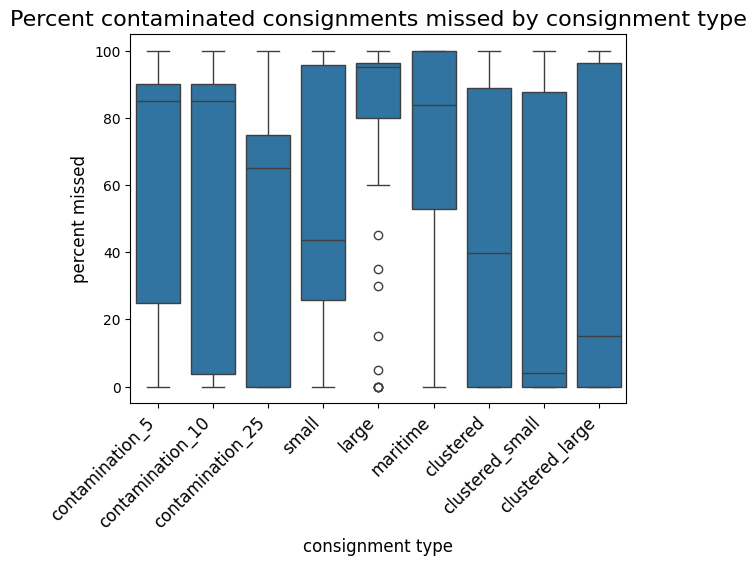

In [22]:
sns.boxplot(x="consignment_name", y="missing", data=df)
plt.xticks(
    rotation=45, 
    horizontalalignment='right',
    fontweight='light',
    fontsize='large'  
)
plt.xlabel("consignment type", size=12)
plt.ylabel("percent missed", size=12)
plt.title("Percent contaminated consignments missed by consignment type", size=16)
plt.savefig("missed_by_inspection_boxplot.png", bbox_inches = "tight")

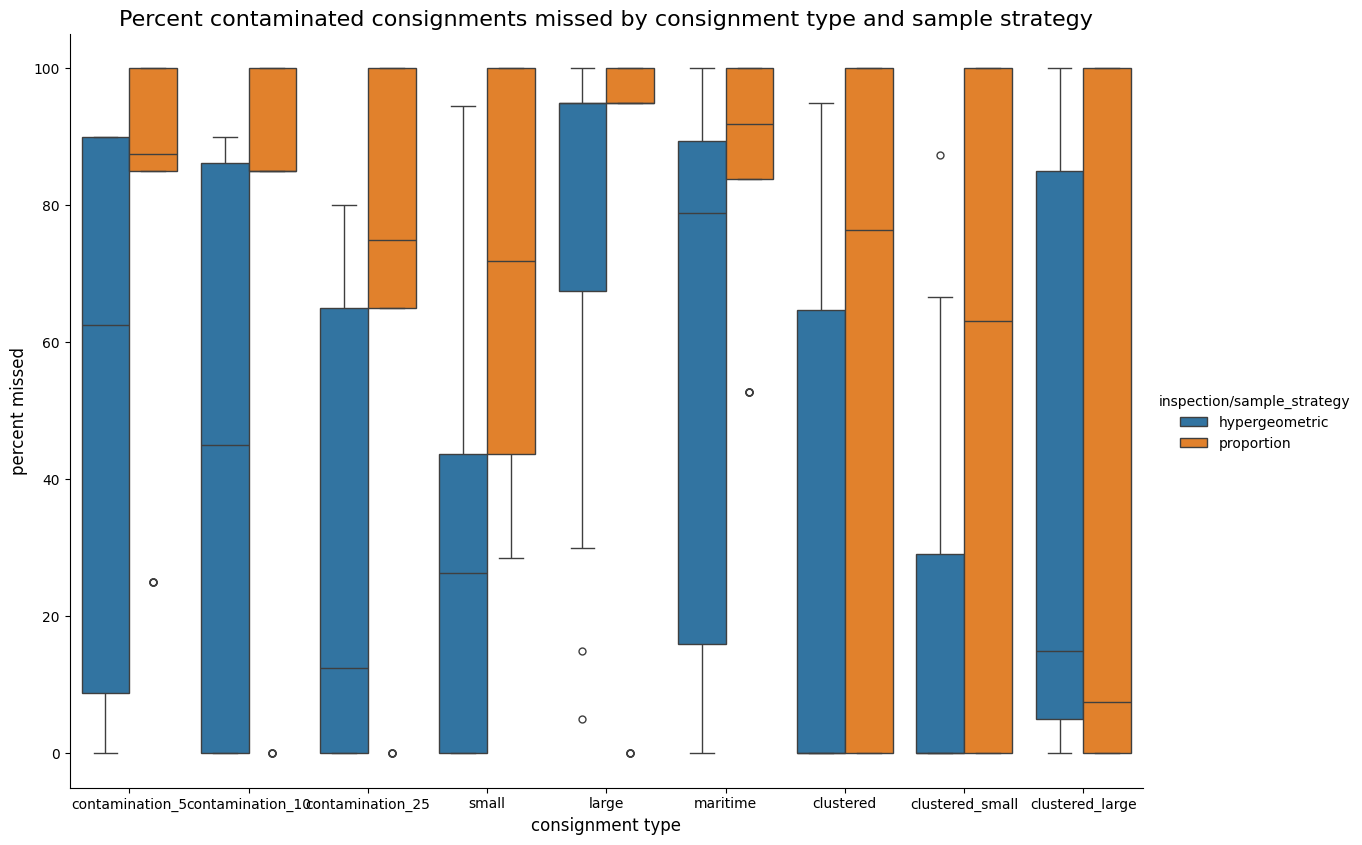

In [23]:
sns.catplot(x="consignment_name", y="missing", hue="inspection/sample_strategy", kind="box", data=df, height=8.27, aspect=11.7/8.27)
plt.xlabel("consignment type", size=12)
plt.ylabel("percent missed", size=12)
plt.title("Percent contaminated consignments missed by consignment type and sample strategy", size=16)
plt.savefig("missed_by_consignment_sample_strategy.png", bbox_inches = "tight")

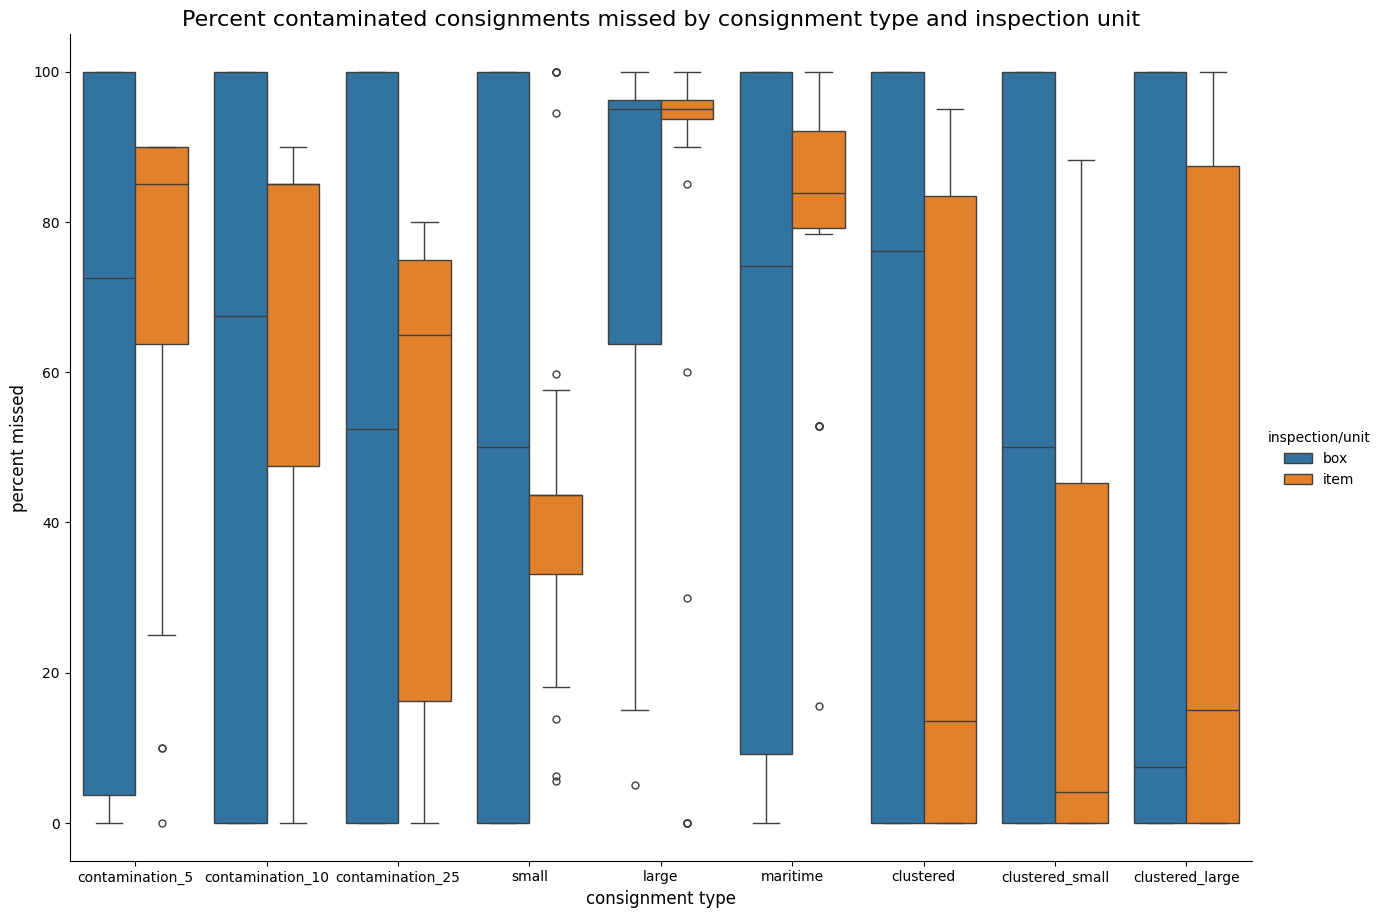

In [24]:
sns.catplot(x="consignment_name", y="missing", hue="inspection/unit", kind="box", data=df, height=9, aspect=11.7/8.27)
plt.xlabel("consignment type", size=12)
plt.ylabel("percent missed", size=12)
plt.title("Percent contaminated consignments missed by consignment type and inspection unit", size=16)
plt.savefig("missed_by_consignment_unit.png", bbox_inches = "tight")

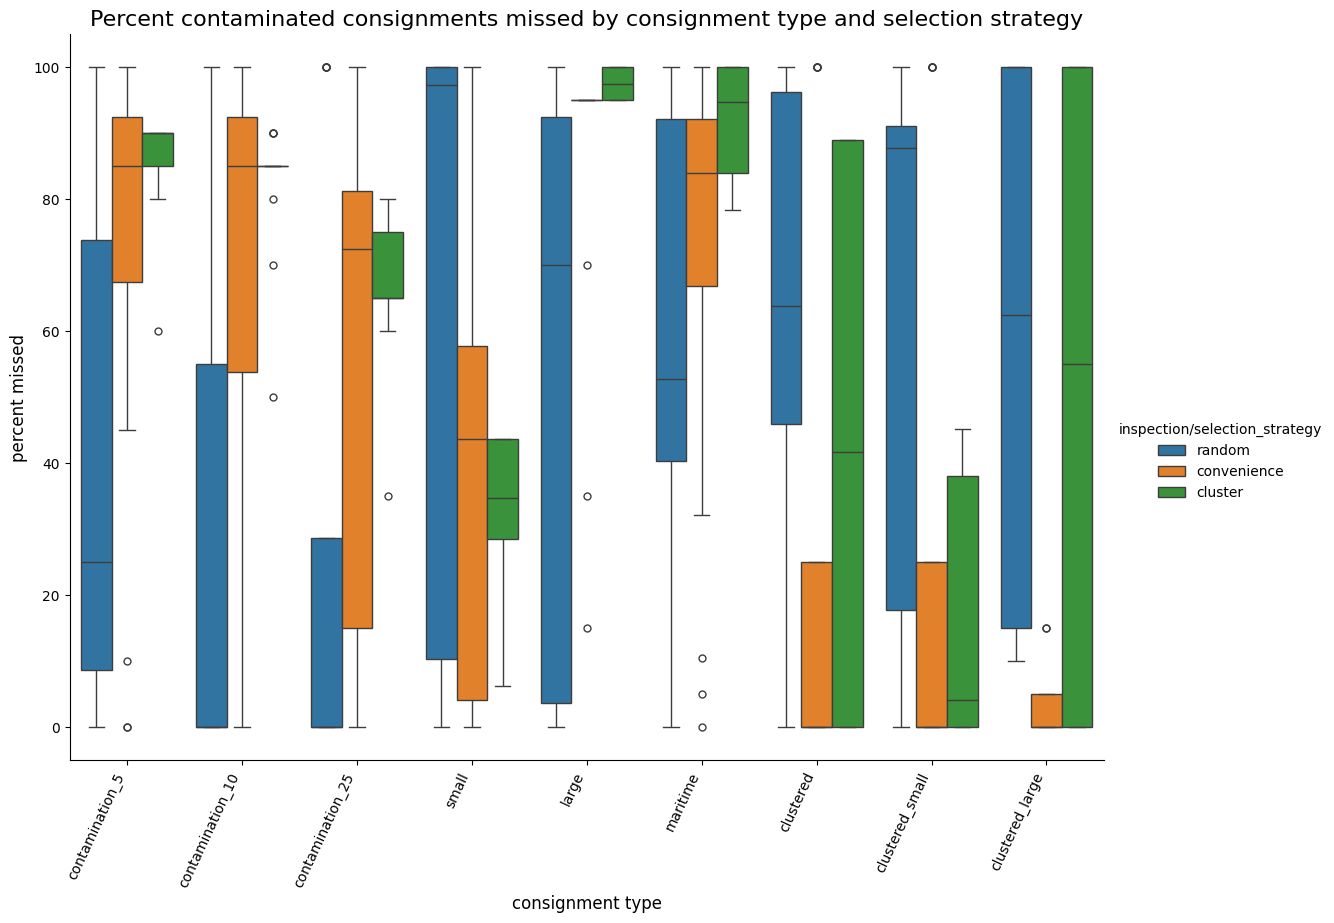

In [25]:
chart = sns.catplot(x="consignment_name", y="missing", hue="inspection/selection_strategy", aspect=11.7/8.27,
            kind="box", data=df, height=8)
chart.set_xticklabels(rotation=65, horizontalalignment='right')
plt.xlabel("consignment type", size=12)
plt.ylabel("percent missed", size=12)
plt.title("Percent contaminated consignments missed by consignment type and selection strategy", size=16)
chart.savefig("missed_by_consignment_selection.png", bbox_inches = "tight")

In [26]:
inspections_vs_consignments

missing  \
consignment_name                              contamination_5   
inspection_name                                                 
boxes 0.01 hypergeometric convenience                     0.0   
boxes 0.01 hypergeometric random                          0.0   
boxes 0.05 hypergeometric convenience                     0.0   
boxes 0.05 hypergeometric random                          0.0   
boxes 0.1 hypergeometric convenience                     10.0   
boxes 0.1 hypergeometric random                           5.0   
boxes 0.25 hypergeometric convenience                    45.0   
boxes 0.25 hypergeometric random                         35.0   
boxes 10% convenience                                   100.0   
boxes 10% random                                        100.0   
boxes 2% convenience                                    100.0   
boxes 2% random                                         100.0   
boxes 25% convenience                                   100.0   
boxes 25% random                                        100.0   
boxes 5% convenience                                    100.0   
boxes 5% random                                         100.0   
items 0.01 hypergeometric cluster convenience            60.0   
items 0.01 hypergeometric cluster random                 80.0   
items 0.01 hypergeometric convenience                    75.0   
items 0.01 hypergeometric random                          0.0   
items 0.05 hypergeometric cluster convenience            90.0   
items 0.05 hypergeometric cluster random                 90.0   
items 0.05 hypergeometric convenience                    90.0   
items 0.05 hypergeometric random                         10.0   
items 0.1 hypergeometric cluster convenience             90.0   
items 0.1 hypergeometric cluster random                  90.0   
items 0.1 hypergeometric convenience                     90.0   
items 0.1 hypergeometric random                          10.0   
items 0.25 hypergeometric cluster convenience            90.0   
items 0.25 hypergeometric cluster random                 90.0   
items 0.25 hypergeometric convenience                    90.0   
items 0.25 hypergeometric random                         65.0   
items 10% cluster convenience                            85.0   
items 10% cluster random                                 90.0   
items 10% convenience                                    85.0   
items 10% random                                         25.0   
items 2% cluster convenience                             85.0   
items 2% cluster random                                  90.0   
items 2% convenience                                     85.0   
items 2% random                                          25.0   
items 25% cluster convenience                            85.0   
items 25% cluster random                                 90.0   
items 25% convenience                                    85.0   
items 25% random                                         25.0   
items 5% cluster convenience                             85.0   
items 5% cluster random                                  90.0   
items 5% convenience                                     85.0   
items 5% random                                          25.0   

                                                                \
consignment_name                              contamination_10   
inspection_name                                                  
boxes 0.01 hypergeometric convenience                      0.0   
boxes 0.01 hypergeometric random                           0.0   
boxes 0.05 hypergeometric convenience                      0.0   
boxes 0.05 hypergeometric random                           0.0   
boxes 0.1 hypergeometric convenience                       0.0   
boxes 0.1 hypergeometric random                            5.0   
boxes 0.25 hypergeometric convenience                     35.0   
boxes 0.25 hypergeometric random                          20.0   
boxes 10% co

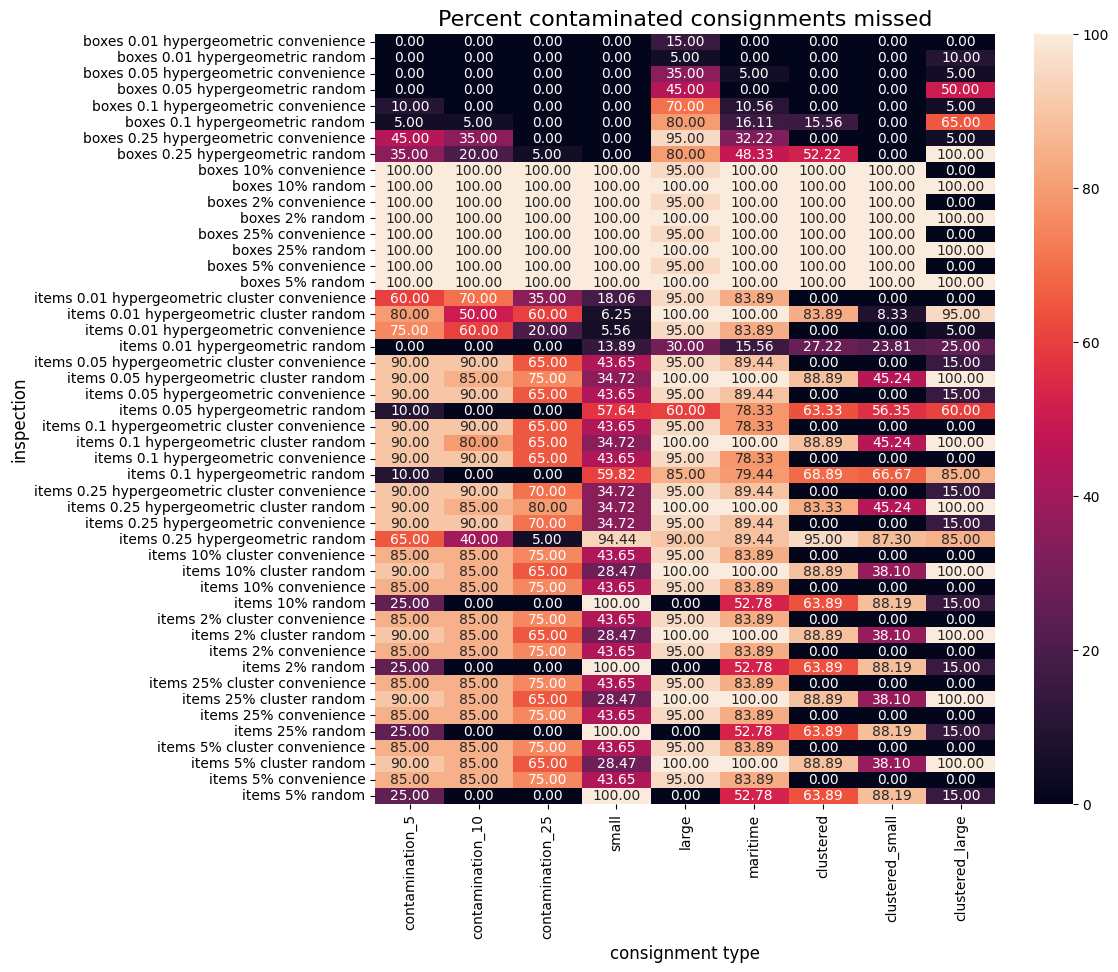

In [27]:
plt.figure(figsize=(10, 10))
sns.heatmap(data=inspections_vs_consignments, annot=True, fmt=".2f", xticklabels = consignment_order)
plt.xlabel("consignment type", size=12)
plt.ylabel("inspection", size=12)
plt.title("Percent contaminated consignments missed", size=16)
plt.savefig("heatmap_missed.png", bbox_inches = "tight")

C:\Users\ling1\AppData\Local\Temp\ipykernel_34220\1122853572.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  inspections_vs_consignments_boxes_opened = df.pivot_table(index=["inspection_name"], columns=["consignment_name"], values=["avg_boxes_opened_completion"])


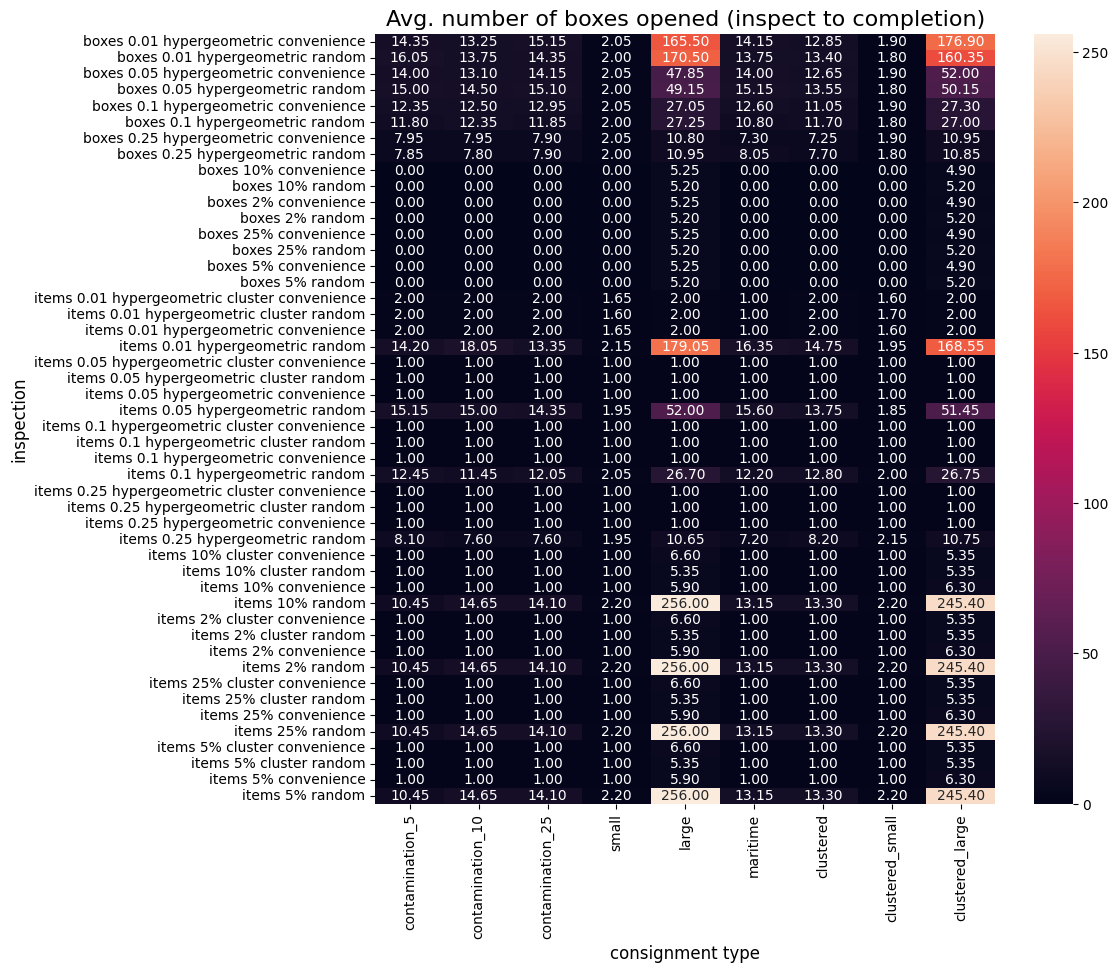

In [28]:
inspections_vs_consignments_boxes_opened = df.pivot_table(index=["inspection_name"], columns=["consignment_name"], values=["avg_boxes_opened_completion"])

plt.figure(figsize=(10, 10))
sns.heatmap(data=inspections_vs_consignments_boxes_opened, annot=True, fmt=".2f", xticklabels = consignment_order)
plt.xlabel("consignment type", size=12)
plt.ylabel("inspection", size=12)
plt.title("Avg. number of boxes opened (inspect to completion)", size=16)
plt.savefig("heatmap_boxes_completion.png", bbox_inches = "tight")

C:\Users\ling1\AppData\Local\Temp\ipykernel_34220\124691405.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  inspections_vs_consignments_items_inspected = df.pivot_table(index=["inspection_name"], columns=["consignment_name"], values=["avg_items_inspected_completion"])


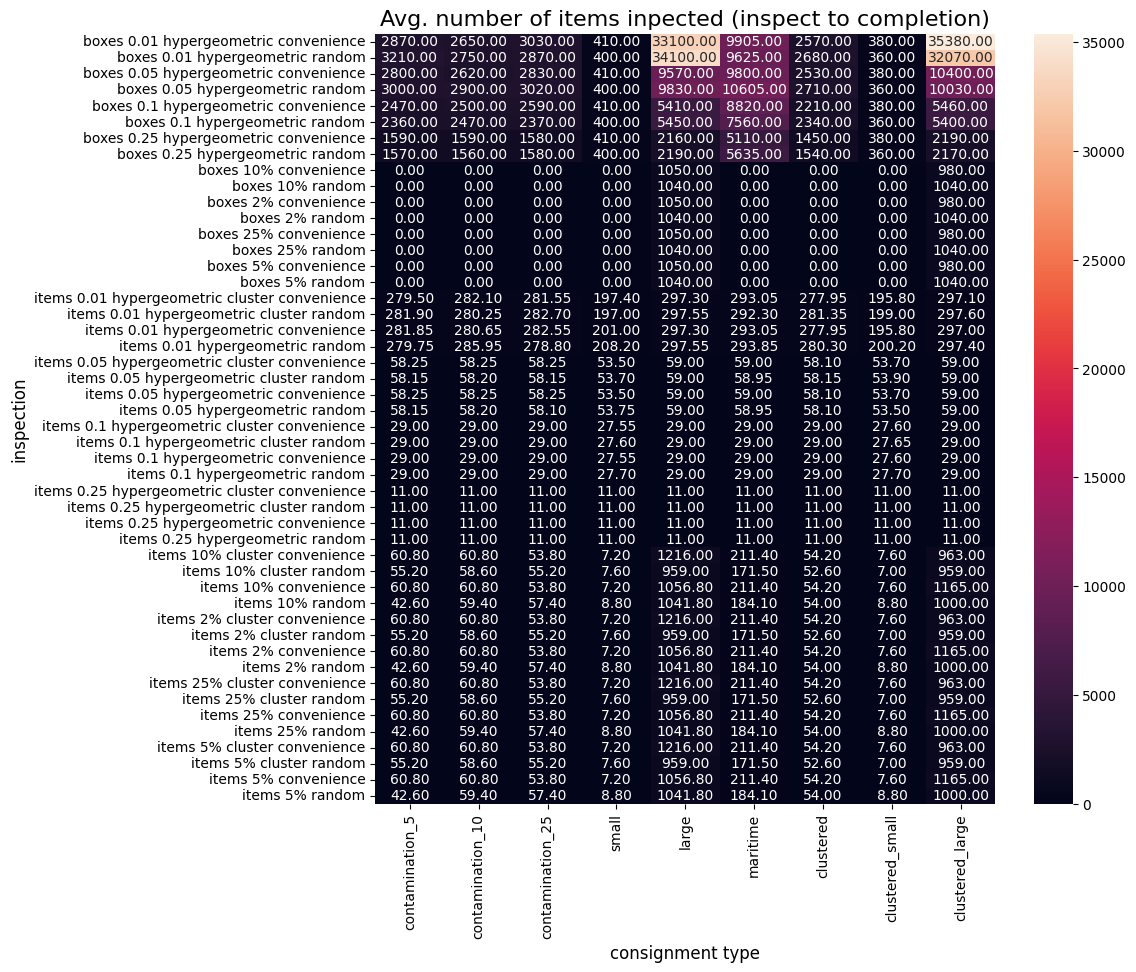

In [29]:
inspections_vs_consignments_items_inspected = df.pivot_table(index=["inspection_name"], columns=["consignment_name"], values=["avg_items_inspected_completion"])

plt.figure(figsize=(10, 10))
sns.heatmap(data=inspections_vs_consignments_items_inspected, annot=True, fmt=".2f", xticklabels = consignment_order)
plt.xlabel("consignment type", size=12)
plt.ylabel("inspection", size=12)
plt.title("Avg. number of items inpected (inspect to completion)", size=16)
plt.savefig("heatmap_items_completion.png", bbox_inches = "tight")

C:\Users\ling1\AppData\Local\Temp\ipykernel_34220\2059424020.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  inspections_vs_consignments_boxes_opened_detection = df.pivot_table(index=["inspection_name"], columns=["consignment_name"], values=["avg_boxes_opened_detection"])


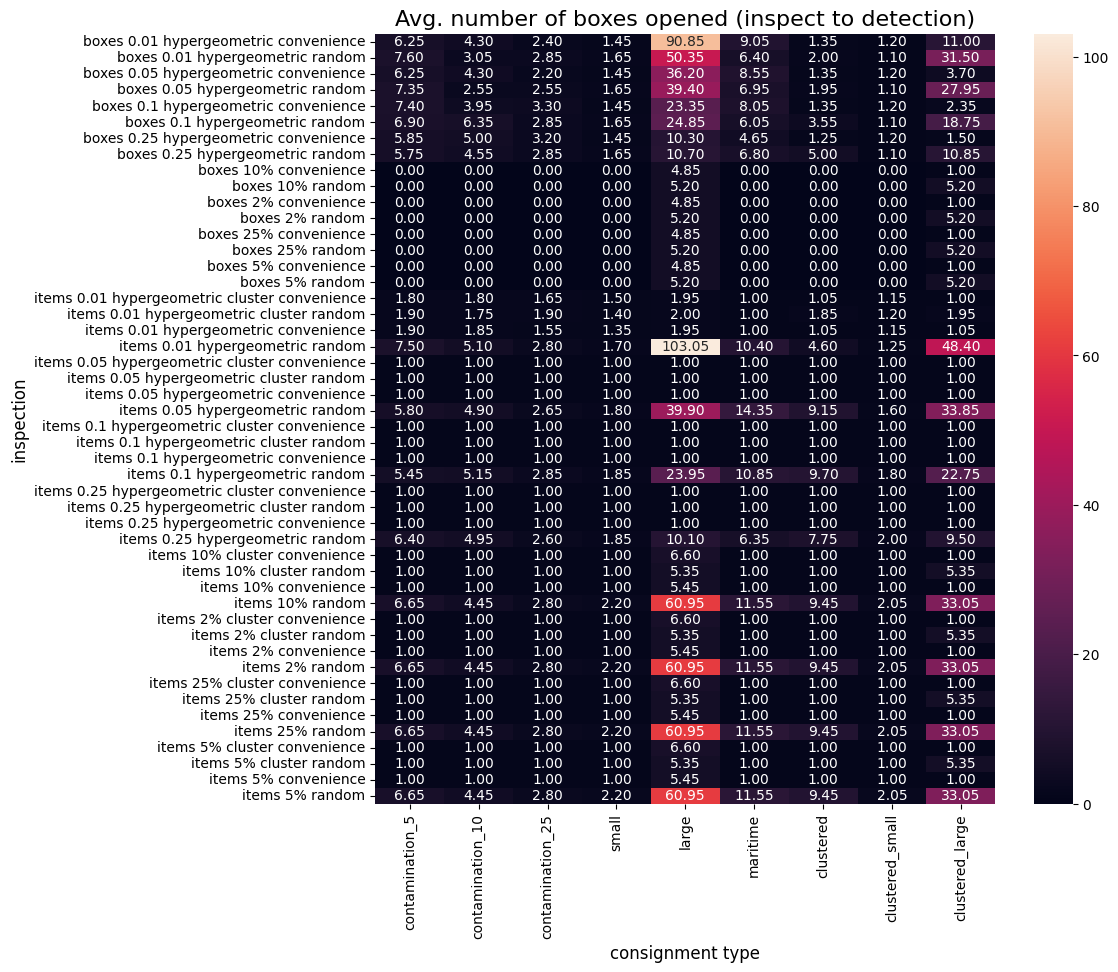

In [30]:
inspections_vs_consignments_boxes_opened_detection = df.pivot_table(index=["inspection_name"], columns=["consignment_name"], values=["avg_boxes_opened_detection"])

plt.figure(figsize=(10, 10))
sns.heatmap(data=inspections_vs_consignments_boxes_opened_detection, annot=True, fmt=".2f", xticklabels = consignment_order)
plt.xlabel("consignment type", size=12)
plt.ylabel("inspection", size=12)
plt.title("Avg. number of boxes opened (inspect to detection)", size=16)
plt.savefig("heatmap_boxes_detection.png", bbox_inches = "tight")

C:\Users\ling1\AppData\Local\Temp\ipykernel_34220\131226977.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  inspections_vs_consignments_items_inspected_detection = df.pivot_table(index=["inspection_name"], columns=["consignment_name"], values=["avg_items_inspected_detection"])


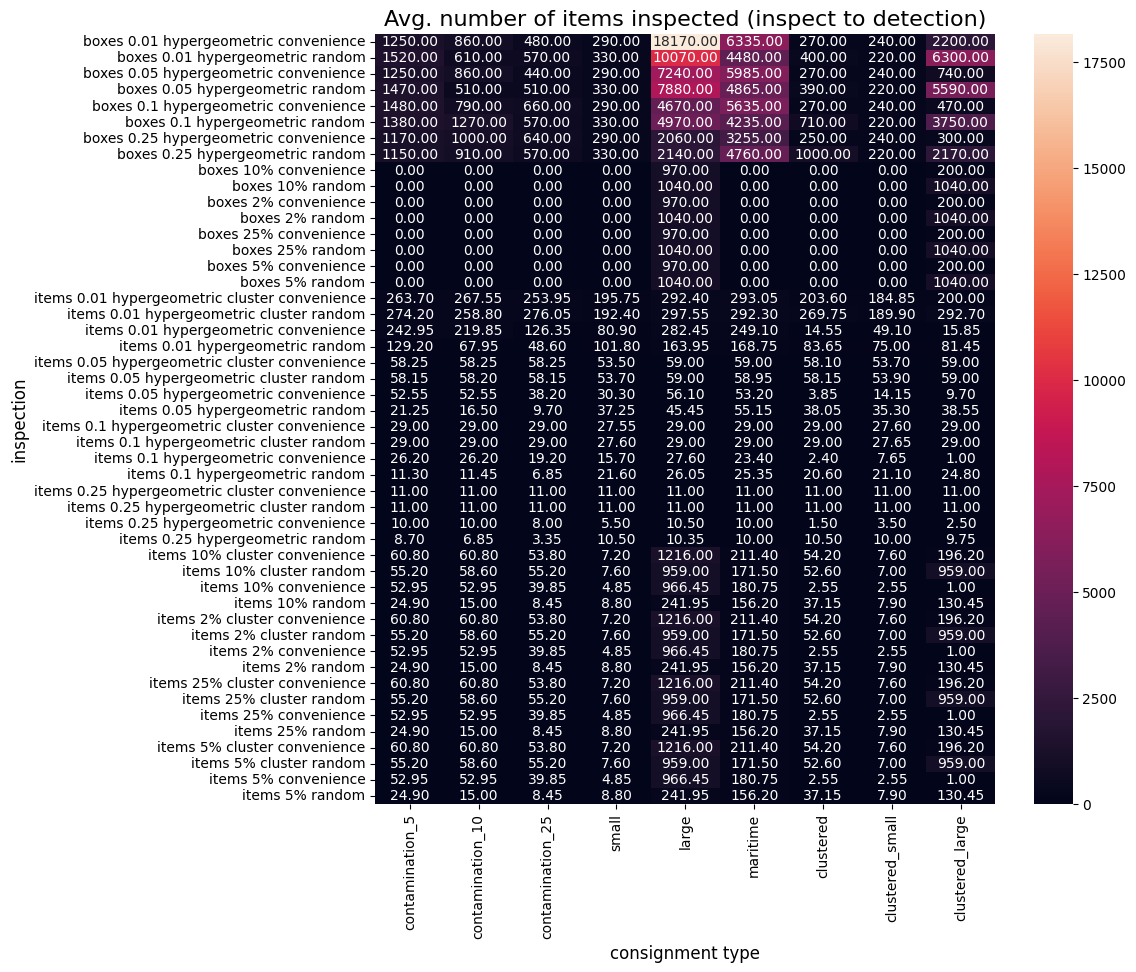

In [31]:
inspections_vs_consignments_items_inspected_detection = df.pivot_table(index=["inspection_name"], columns=["consignment_name"], values=["avg_items_inspected_detection"])

plt.figure(figsize=(10, 10))
sns.heatmap(data=inspections_vs_consignments_items_inspected_detection, annot=True, fmt=".2f", xticklabels = consignment_order)
plt.xlabel("consignment type", size=12)
plt.ylabel("inspection", size=12)
plt.title("Avg. number of items inspected (inspect to detection)", size=16)
plt.savefig("heatmap_items_detection.png", bbox_inches = "tight")

In [32]:
df_norm = df[["missing",
        "true_contamination_rate",
        "max_intercepted_contamination_rate",
        "avg_intercepted_contamination_rate",
        "avg_boxes_opened_completion",
        "avg_boxes_opened_detection",
        "avg_items_inspected_completion",
        "avg_items_inspected_detection",
        "pct_items_inspected_detection",
        "pct_contaminant_unreported_if_detection"]]
df_norm

,missing,true_contamination_rate,max_intercepted_contamination_rate,avg_intercepted_contamination_rate,avg_boxes_opened_completion,avg_boxes_opened_detection,avg_items_inspected_completion,avg_items_inspected_detection,pct_items_inspected_detection,pct_contaminant_unreported_if_detection
0,0.000000,0.007177,0.018064,0.007532,13.40,2.00,2680.0,400.00,14.058645,0.000000
1,0.000000,0.007162,0.018129,0.007516,13.55,1.95,2710.0,390.00,13.275576,0.000000
2,15.555556,0.007248,0.018229,0.007348,11.70,3.55,2340.0,710.00,26.396262,0.000000
3,52.222222,0.007186,0.013309,0.007056,7.70,5.00,1540.0,1000.00,33.991995,0.000000
4,0.000000,0.007166,0.018105,0.007519,12.85,1.35,2570.0,270.00,10.456804,0.000000
...,...,...,...,...,...,...,...,...,...,...
427,100.000000,0.007417,NaN,NaN,2.20,2.20,8.8,8.80,2.000000,0.000000
428,43.650794,0.014750,0.042500,0.020417,1.00,1.00,7.2,4.85,1.344427,66.746411
429,43.650794,0.014750,0.042500,0.020417,1.00,1.00,7.2,4.85,1.344427,66.746411
430,43.650794,0.014750,0.042500,0.020417,1.00,1.00,7.2,4.85,1.344427,66.746411


In [33]:
df_norm=(df_norm-df_norm.min())/(df_norm.max()-df_norm.min())
df_norm

,missing,true_contamination_rate,max_intercepted_contamination_rate,avg_intercepted_contamination_rate,avg_boxes_opened_completion,avg_boxes_opened_detection,avg_items_inspected_completion,avg_items_inspected_detection,pct_items_inspected_detection,pct_contaminant_unreported_if_detection
0,0.000000,0.002500,0.046082,0.015420,0.052344,0.019408,0.075749,0.022014,0.170758,0.000000
1,0.000000,0.002443,0.046303,0.015361,0.052930,0.018923,0.076597,0.021464,0.161247,0.000000
2,0.155556,0.002775,0.046645,0.014716,0.045703,0.034449,0.066139,0.039075,0.320612,0.000000
3,0.522222,0.002537,0.029913,0.013598,0.030078,0.048520,0.043527,0.055036,0.412871,0.000000
4,0.000000,0.002458,0.046221,0.015371,0.050195,0.013100,0.072640,0.014860,0.127010,0.000000
...,...,...,...,...,...,...,...,...,...,...
427,1.000000,0.003428,NaN,NaN,0.008594,0.021349,0.000249,0.000484,0.024292,0.000000
428,0.436508,0.031792,0.129185,0.064698,0.003906,0.009704,0.000204,0.000267,0.016330,0.668776
429,0.436508,0.031792,0.129185,0.064698,0.003906,0.009704,0.000204,0.000267,0.016330,0.668776
430,0.436508,0.031792,0.129185,0.064698,0.003906,0.009704,0.000204,0.000267,0.016330,0.668776


In [34]:
df_norm["name"], df_norm["inspection_num"], df_norm["inspection_name"], df_norm["consignment_name"] = df["name"], df["inspection_num"], df["inspection_name"], df["consignment_name"]
df_norm

,missing,true_contamination_rate,max_intercepted_contamination_rate,avg_intercepted_contamination_rate,avg_boxes_opened_completion,avg_boxes_opened_detection,avg_items_inspected_completion,avg_items_inspected_detection,pct_items_inspected_detection,pct_contaminant_unreported_if_detection,name,inspection_num,inspection_name,consignment_name
0,0.000000,0.002500,0.046082,0.015420,0.052344,0.019408,0.075749,0.022014,0.170758,0.000000,clustered_10,1,boxes 0.01 hypergeometric random,clustered
1,0.000000,0.002443,0.046303,0.015361,0.052930,0.018923,0.076597,0.021464,0.161247,0.000000,clustered_12,2,boxes 0.05 hypergeometric random,clustered
2,0.155556,0.002775,0.046645,0.014716,0.045703,0.034449,0.066139,0.039075,0.320612,0.000000,clustered_14,3,boxes 0.1 hypergeometric random,clustered
3,0.522222,0.002537,0.029913,0.013598,0.030078,0.048520,0.043527,0.055036,0.412871,0.000000,clustered_16,4,boxes 0.25 hypergeometric random,clustered
4,0.000000,0.002458,0.046221,0.015371,0.050195,0.013100,0.072640,0.014860,0.127010,0.000000,clustered_09,5,boxes 0.01 hypergeometric convenience,clustered
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,1.000000,0.003428,NaN,NaN,0.008594,0.021349,0.000249,0.000484,0.024292,0.000000,small_30,44,items 25% random,small
428,0.436508,0.031792,0.129185,0.064698,0.003906,0.009704,0.000204,0.000267,0.016330,0.668776,small_17,45,items 2% convenience,small
429,0.436508,0.031792,0.129185,0.064698,0.003906,0.009704,0.000204,0.000267,0.016330,0.668776,small_21,46,items 5% convenience,small
430,0.436508,0.031792,0.129185,0.064698,0.003906,0.009704,0.000204,0.000267,0.016330,0.668776,small_25,47,items 10% convenience,small


C:\Users\ling1\AppData\Local\Temp\ipykernel_34220\2236039774.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  chart = sns.barplot(x="inspection_name", y="value", hue="variable",\


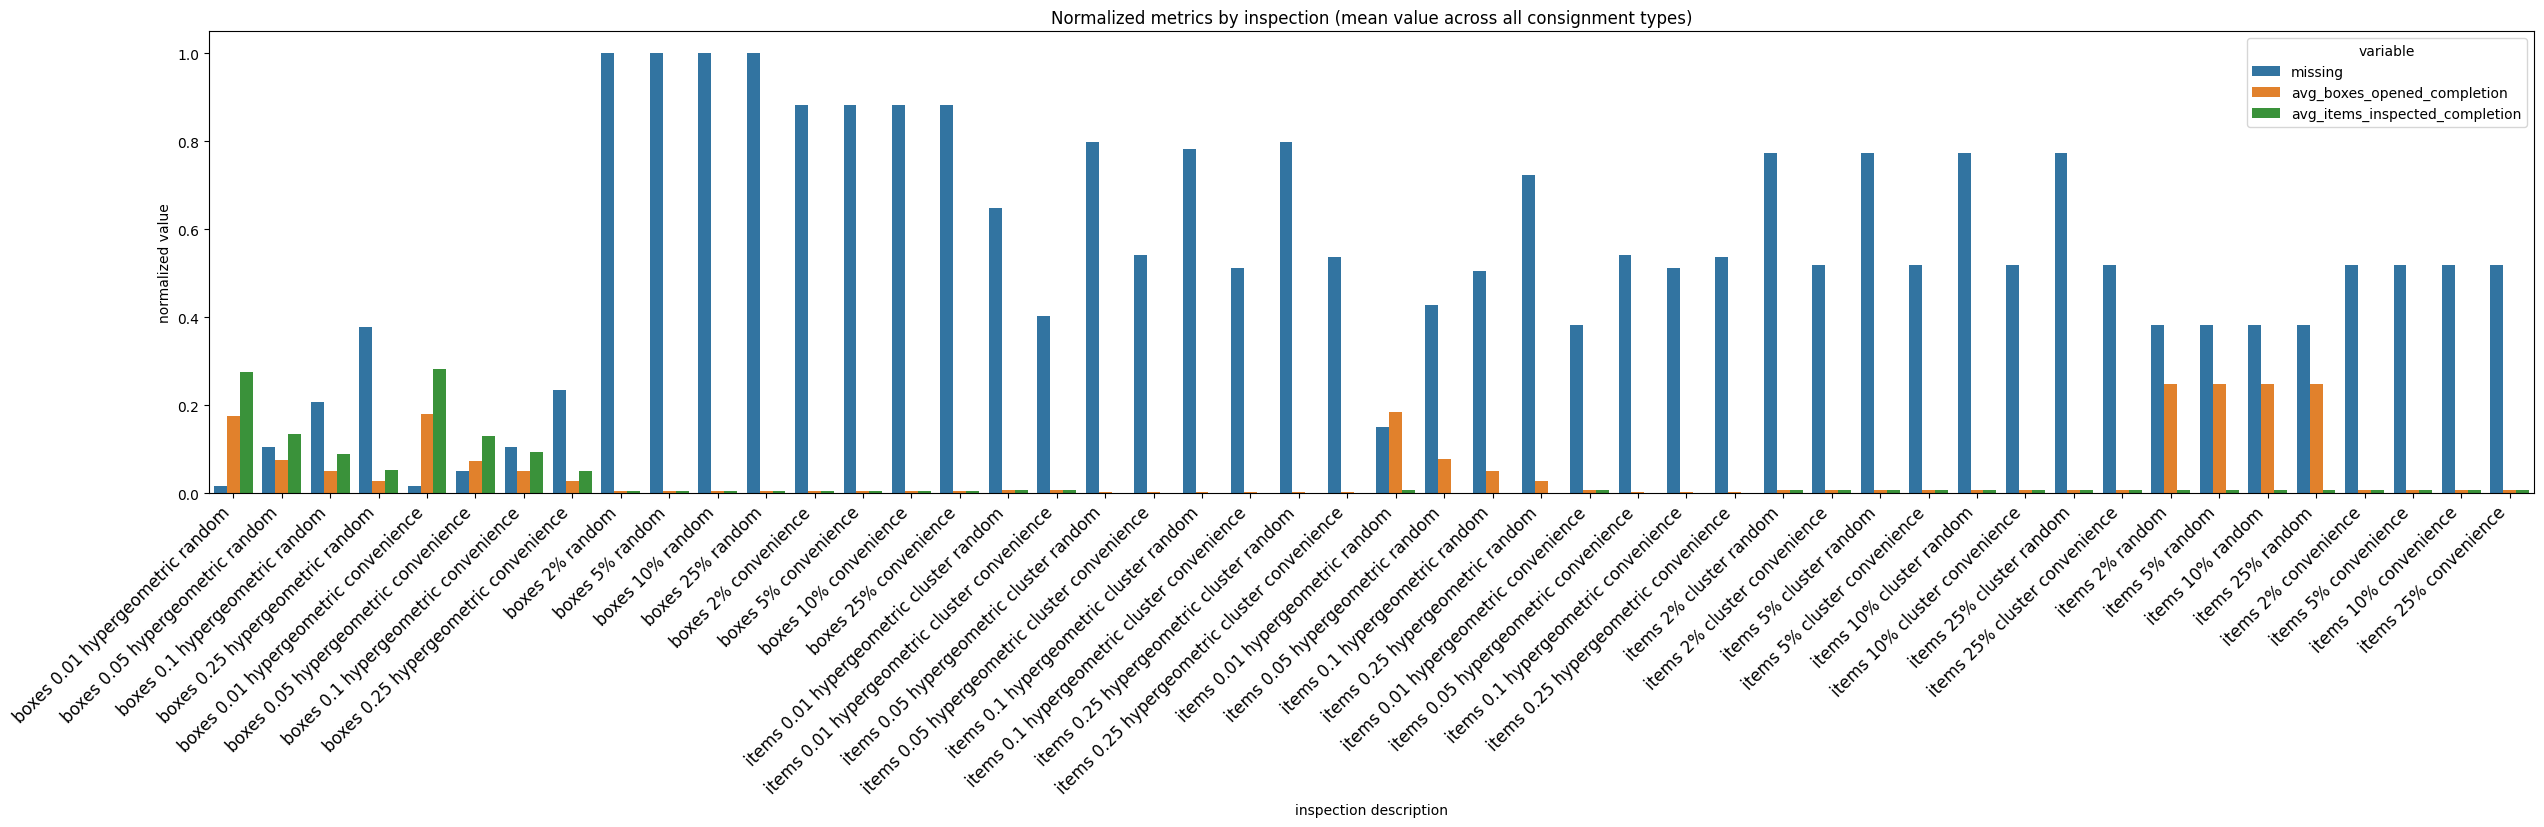

In [35]:
df_norm_melted = pd.melt(df_norm, id_vars=["inspection_num", "inspection_name", "consignment_name"], value_vars=["missing", "avg_boxes_opened_completion", "avg_items_inspected_completion"])
fig, ax1 = plt.subplots(figsize=(30, 6))
chart = sns.barplot(x="inspection_name", y="value", hue="variable",\
                data=df_norm_melted, ax=ax1, ci = None)
plt.xticks(
    rotation=45, 
    horizontalalignment='right',
    fontweight='light',
    fontsize='large'  
)
plt.title("Normalized metrics by inspection (mean value across all consignment types)")
plt.xlabel("inspection description")
plt.ylabel("normalized value")
plt.savefig("metrics_by_inspection_all.png", bbox_inches = "tight")

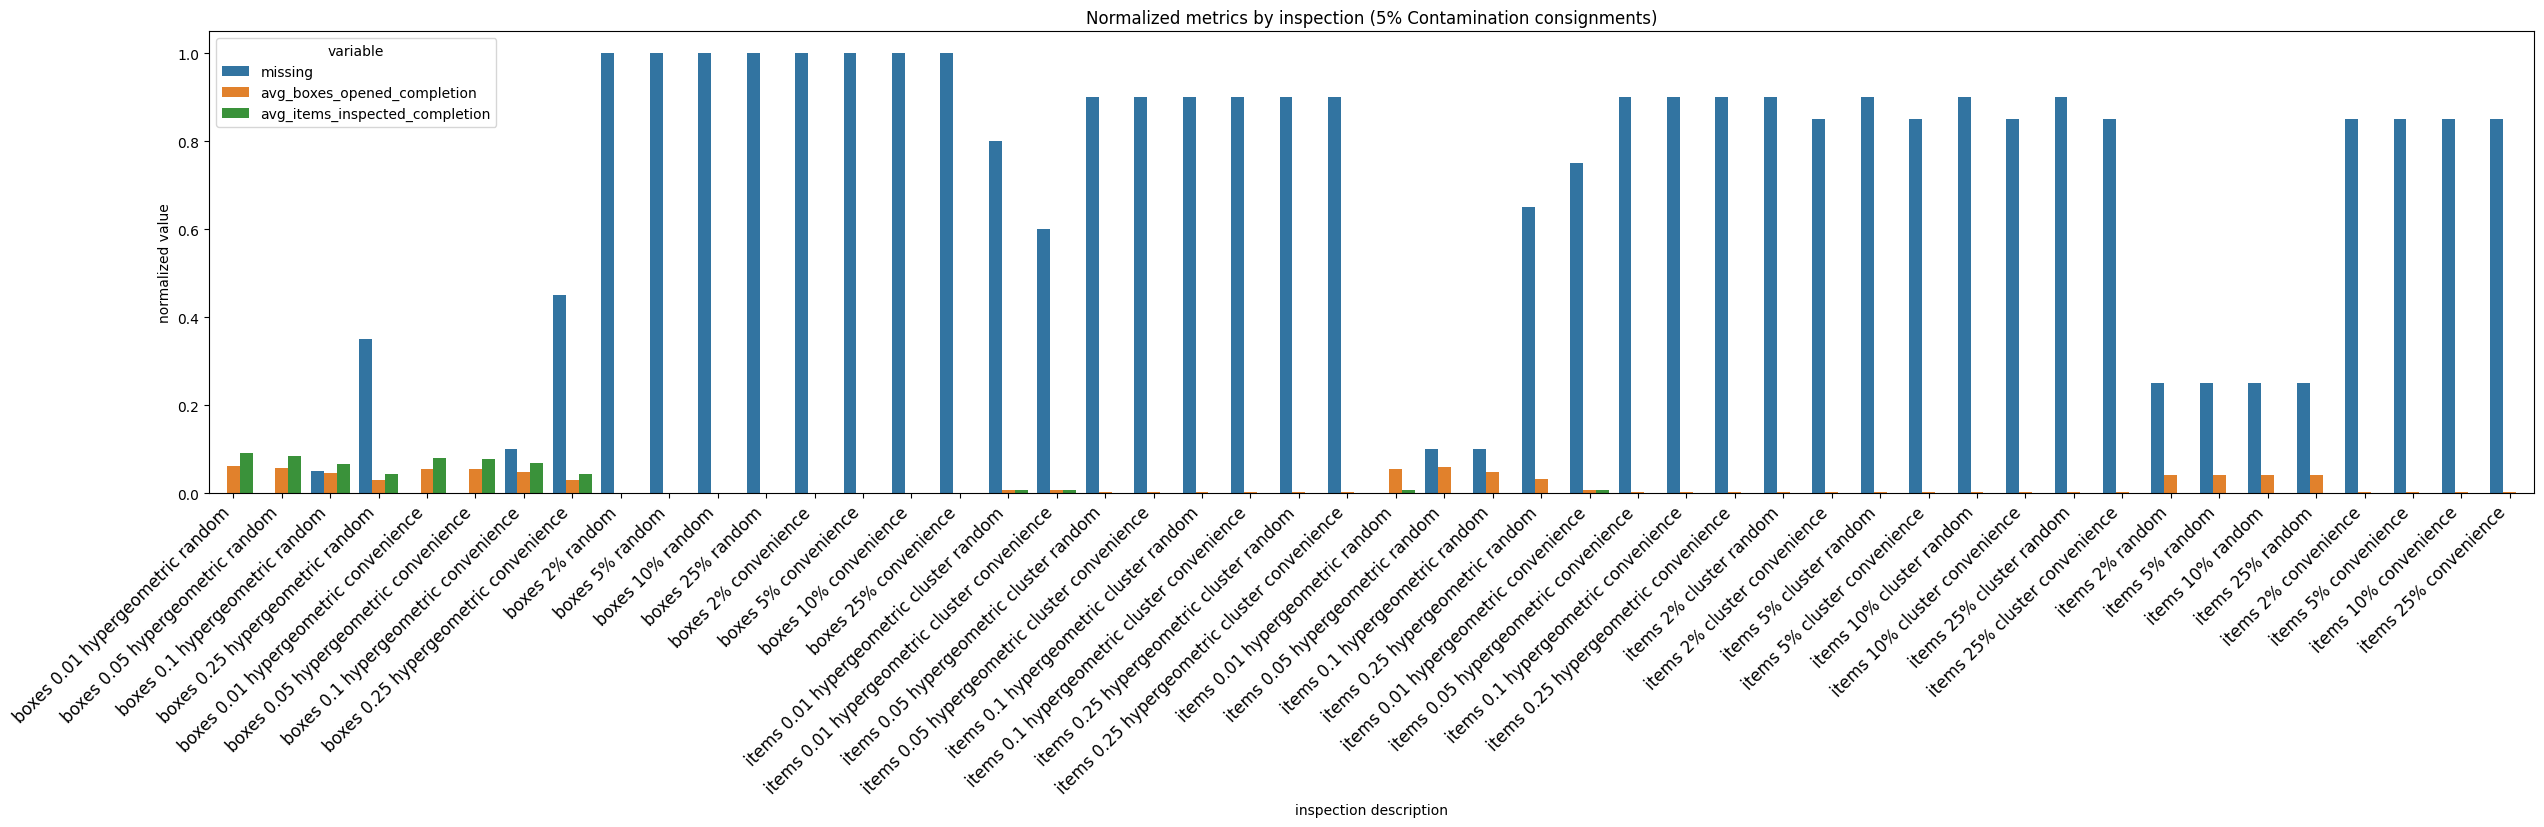

In [36]:
fig, ax1 = plt.subplots(figsize=(30, 6))
chart = sns.barplot(x="inspection_name", y="value", hue="variable",\
                data=df_norm_melted[df_norm_melted.consignment_name.eq("contamination_5")], ax=ax1)
plt.xticks(
    rotation=45, 
    horizontalalignment='right',
    fontweight='light',
    fontsize='large'  
)
plt.title("Normalized metrics by inspection (5% Contamination consignments)")
plt.xlabel("inspection description")
plt.ylabel("normalized value")
plt.savefig("metrics_by_inspection_contamination_5.png", bbox_inches = "tight")

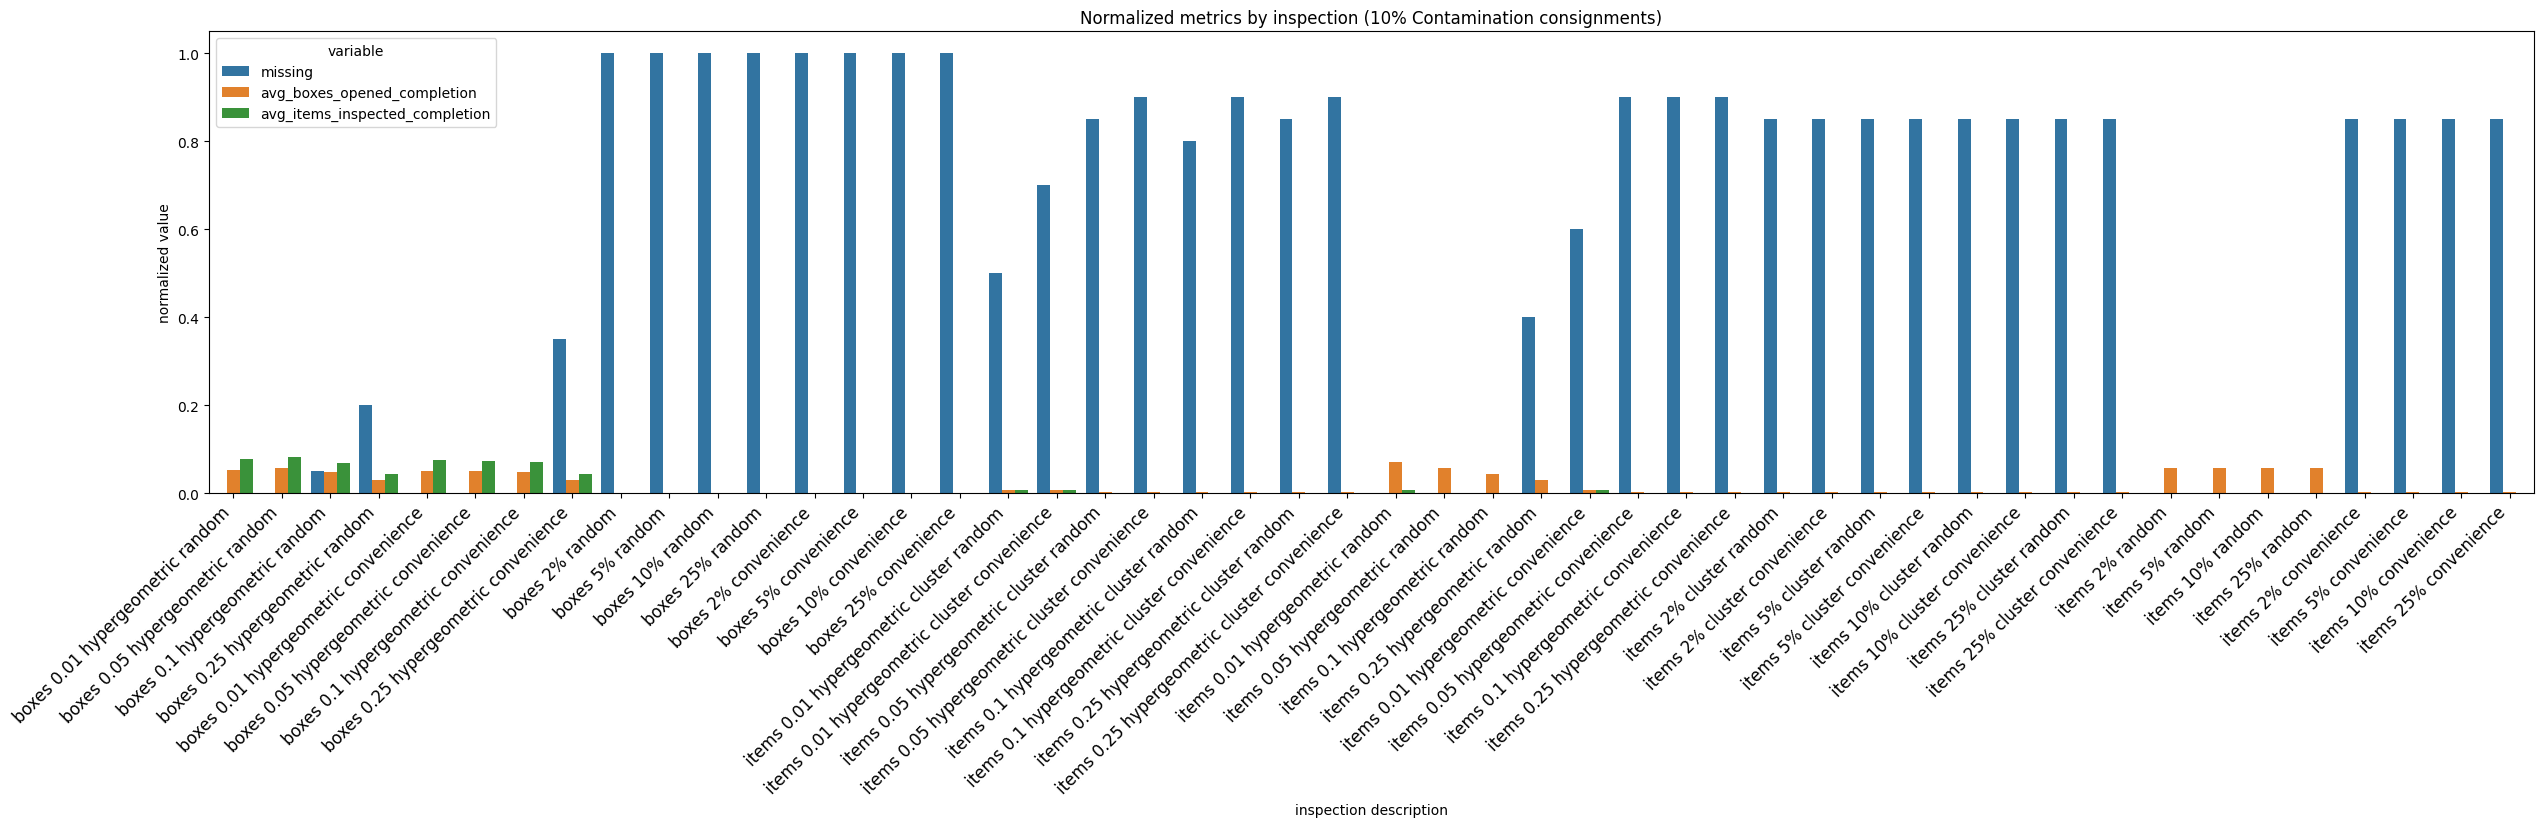

In [37]:
fig, ax1 = plt.subplots(figsize=(30, 6))
chart = sns.barplot(x="inspection_name", y="value", hue="variable",\
                data=df_norm_melted[df_norm_melted.consignment_name.eq("contamination_10")], ax=ax1)
plt.xticks(
    rotation=45, 
    horizontalalignment='right',
    fontweight='light',
    fontsize='large'  
)
plt.title("Normalized metrics by inspection (10% Contamination consignments)")
plt.xlabel("inspection description")
plt.ylabel("normalized value")
plt.savefig("metrics_by_inspection_contamination_10.png", bbox_inches = "tight")

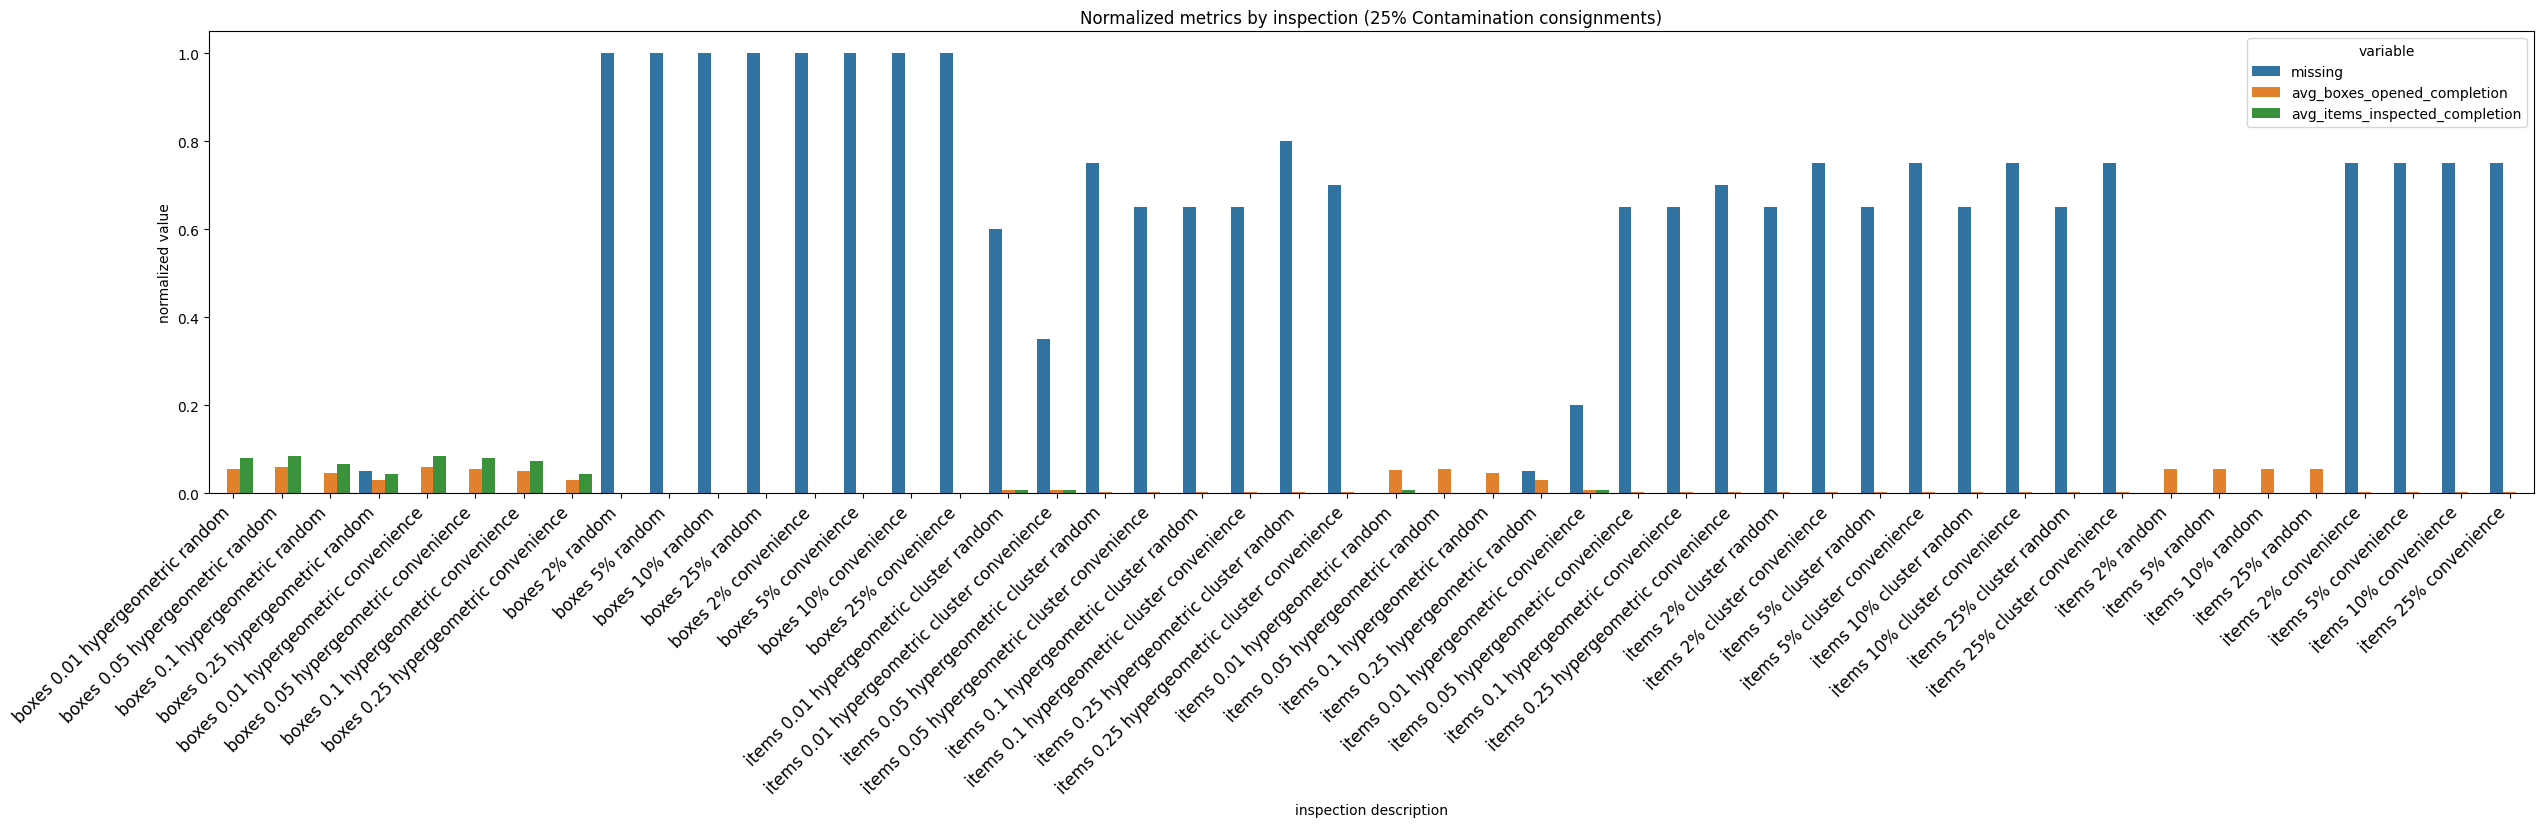

In [38]:
fig, ax1 = plt.subplots(figsize=(30, 6))
chart = sns.barplot(x="inspection_name", y="value", hue="variable",\
                data=df_norm_melted[df_norm_melted.consignment_name.eq("contamination_25")], ax=ax1)
plt.xticks(
    rotation=45, 
    horizontalalignment='right',
    fontweight='light',
    fontsize='large'  
)
plt.title("Normalized metrics by inspection (25% Contamination consignments)")
plt.xlabel("inspection description")
plt.ylabel("normalized value")
plt.savefig("metrics_by_inspection_contamination_25.png", bbox_inches = "tight")

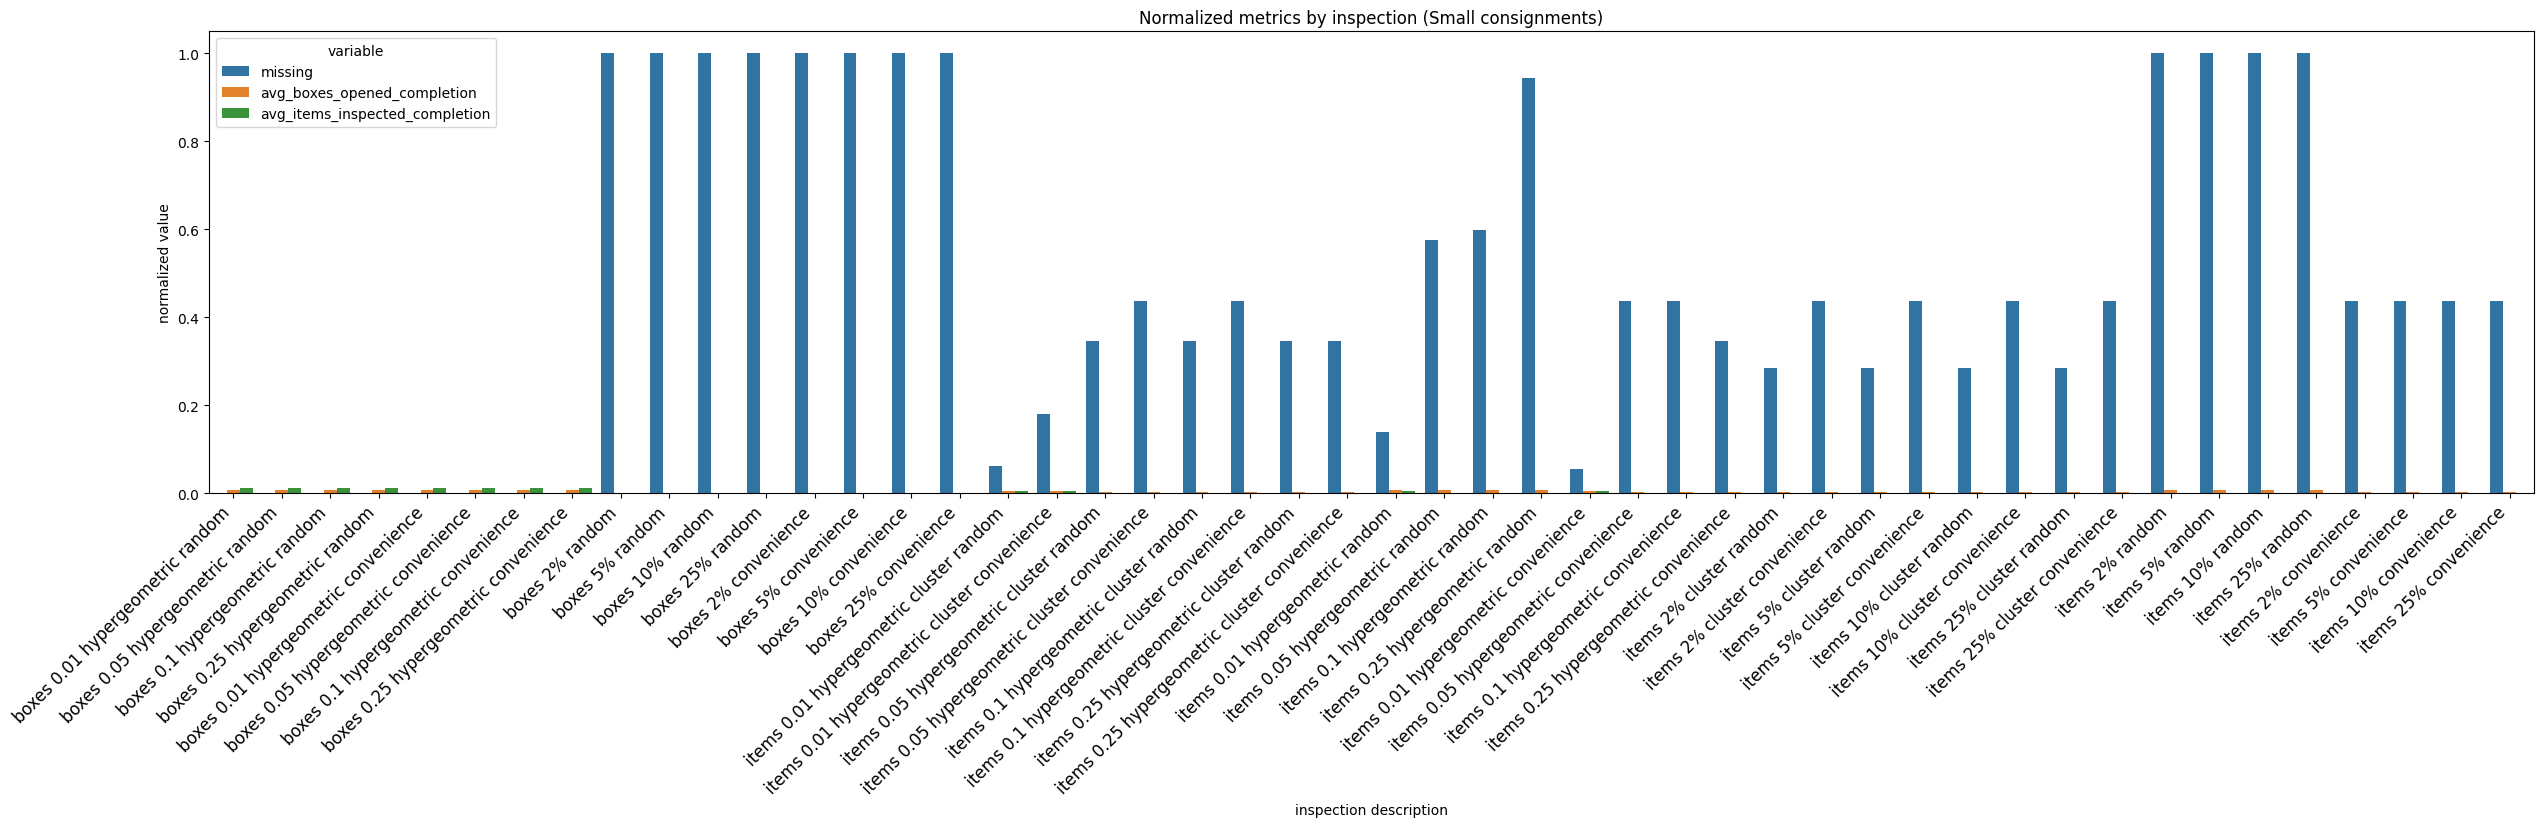

In [39]:
fig, ax1 = plt.subplots(figsize=(30, 6))
chart = sns.barplot(x="inspection_name", y="value", hue="variable",\
                data=df_norm_melted[df_norm_melted.consignment_name.eq("small")], ax=ax1)
plt.xticks(
    rotation=45, 
    horizontalalignment='right',
    fontweight='light',
    fontsize='large'  
)
plt.title("Normalized metrics by inspection (Small consignments)")
plt.xlabel("inspection description")
plt.ylabel("normalized value")
plt.savefig("metrics_by_inspection_small.png", bbox_inches = "tight")

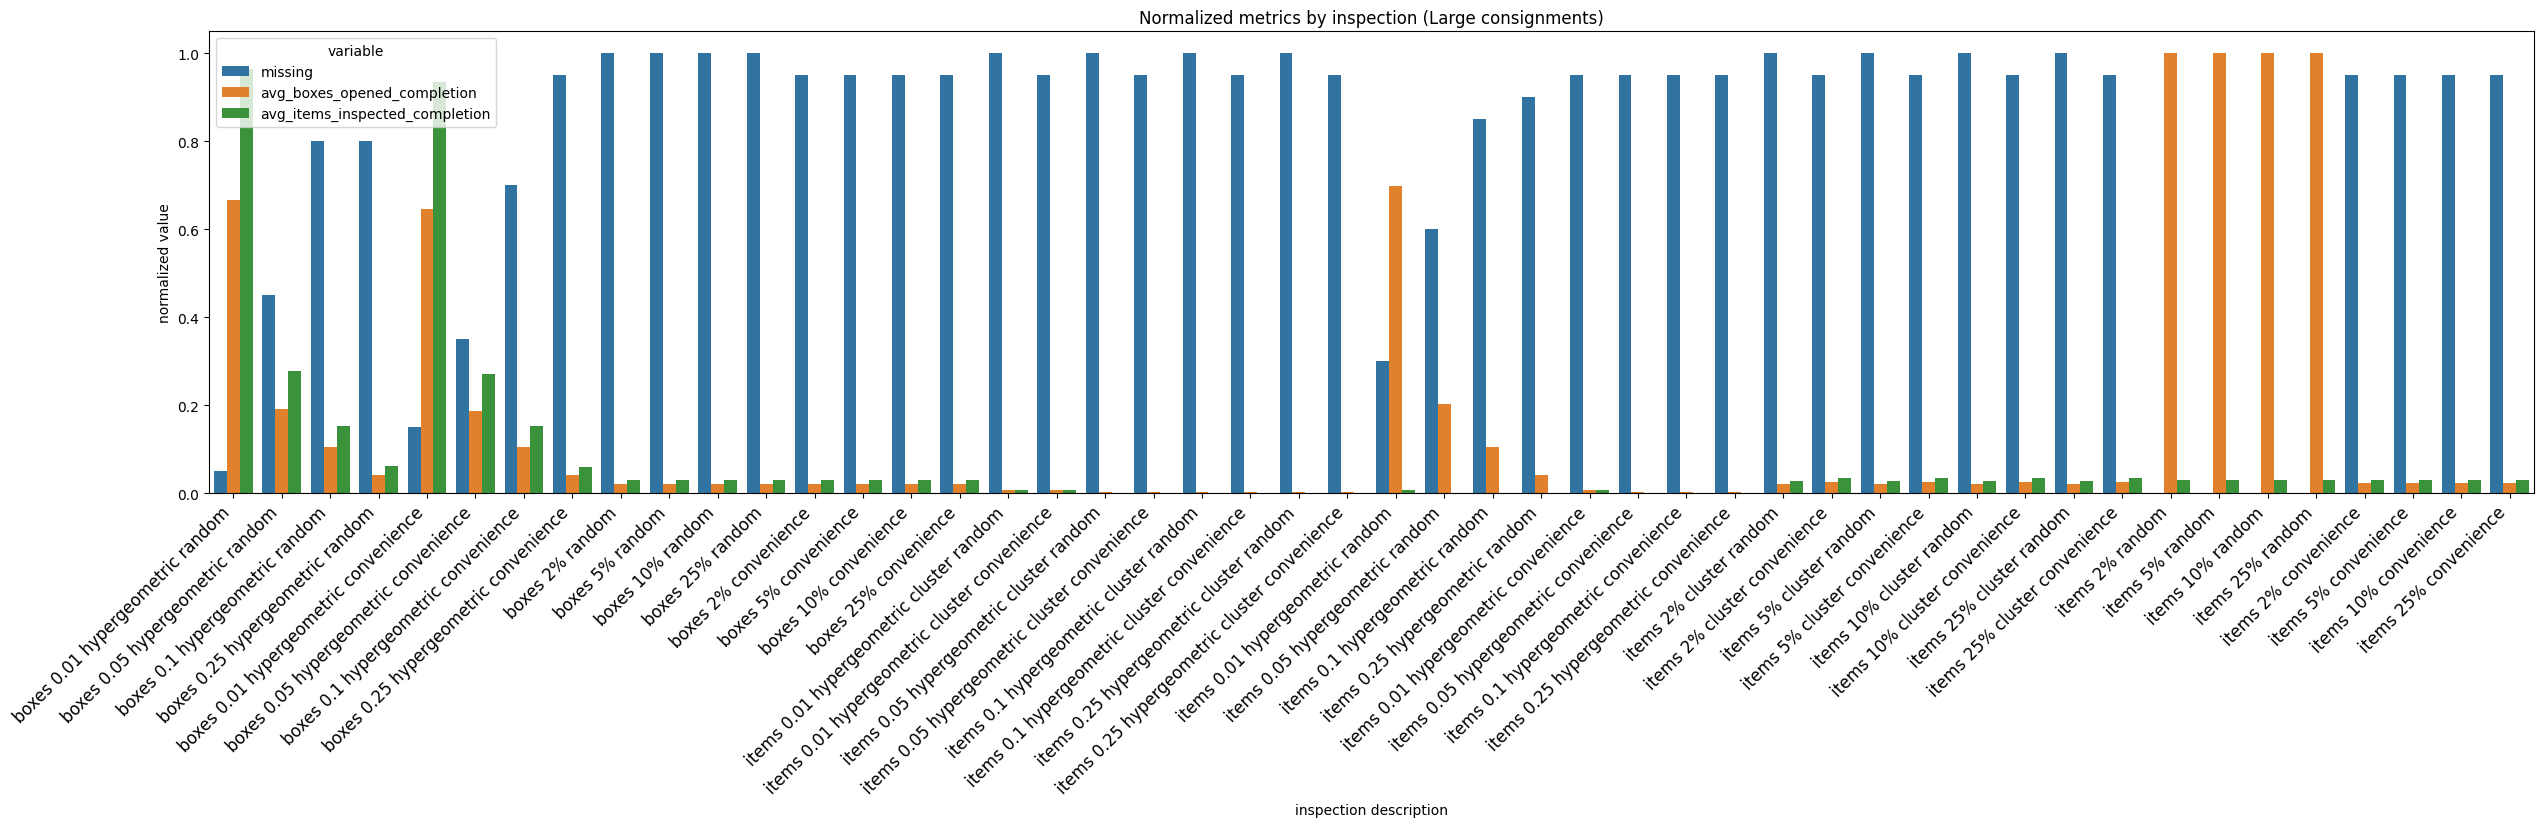

In [40]:
fig, ax1 = plt.subplots(figsize=(30, 6))
chart = sns.barplot(x="inspection_name", y="value", hue="variable",\
                data=df_norm_melted[df_norm_melted.consignment_name.eq("large")], ax=ax1)
plt.xticks(
    rotation=45, 
    horizontalalignment='right',
    fontweight='light',
    fontsize='large'  
)
plt.title("Normalized metrics by inspection (Large consignments)")
plt.xlabel("inspection description")
plt.ylabel("normalized value")
plt.savefig("metrics_by_inspection_large.png", bbox_inches = "tight")

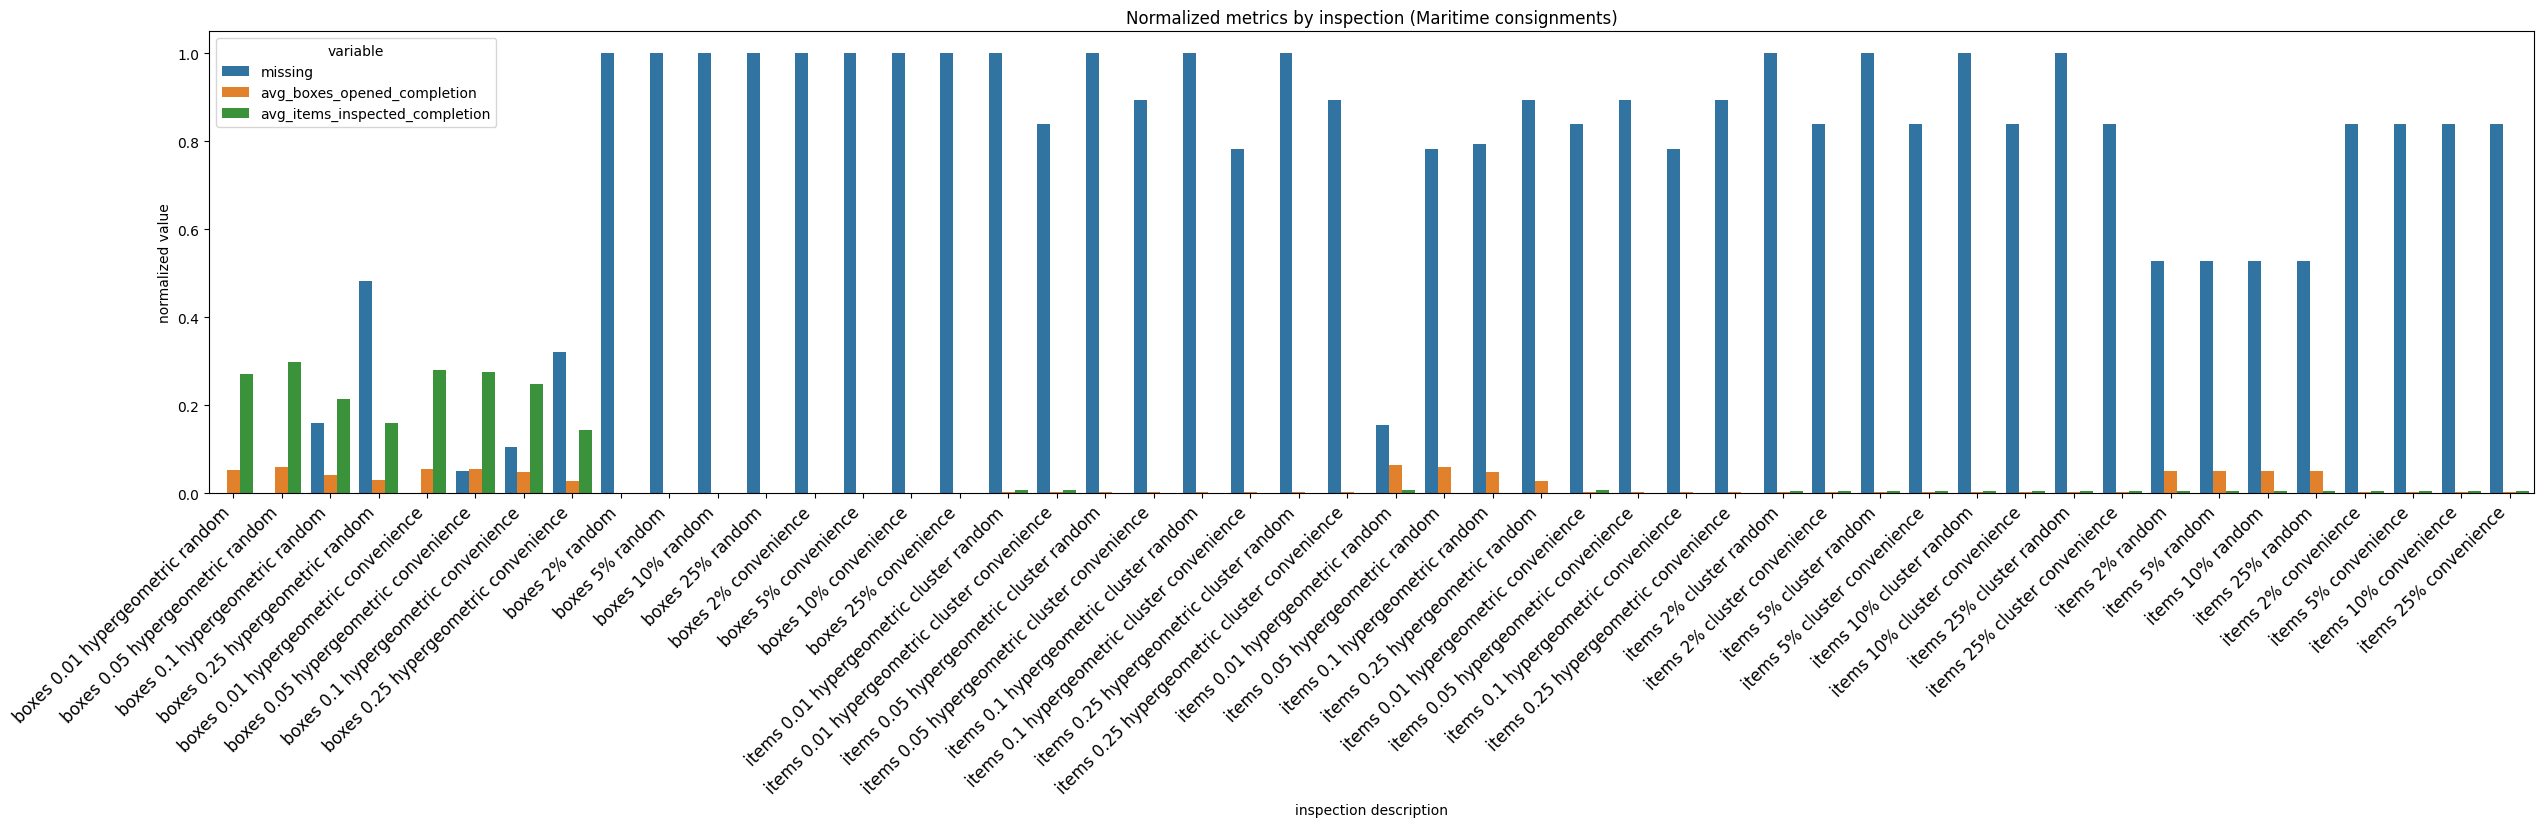

In [41]:
fig, ax1 = plt.subplots(figsize=(30, 6))
chart = sns.barplot(x="inspection_name", y="value", hue="variable",\
                data=df_norm_melted[df_norm_melted.consignment_name.eq("maritime")], ax=ax1)
plt.xticks(
    rotation=45, 
    horizontalalignment='right',
    fontweight='light',
    fontsize='large'  
)
plt.title("Normalized metrics by inspection (Maritime consignments)")
plt.xlabel("inspection description")
plt.ylabel("normalized value")
plt.savefig("metrics_by_inspection_maritime.png", bbox_inches = "tight")

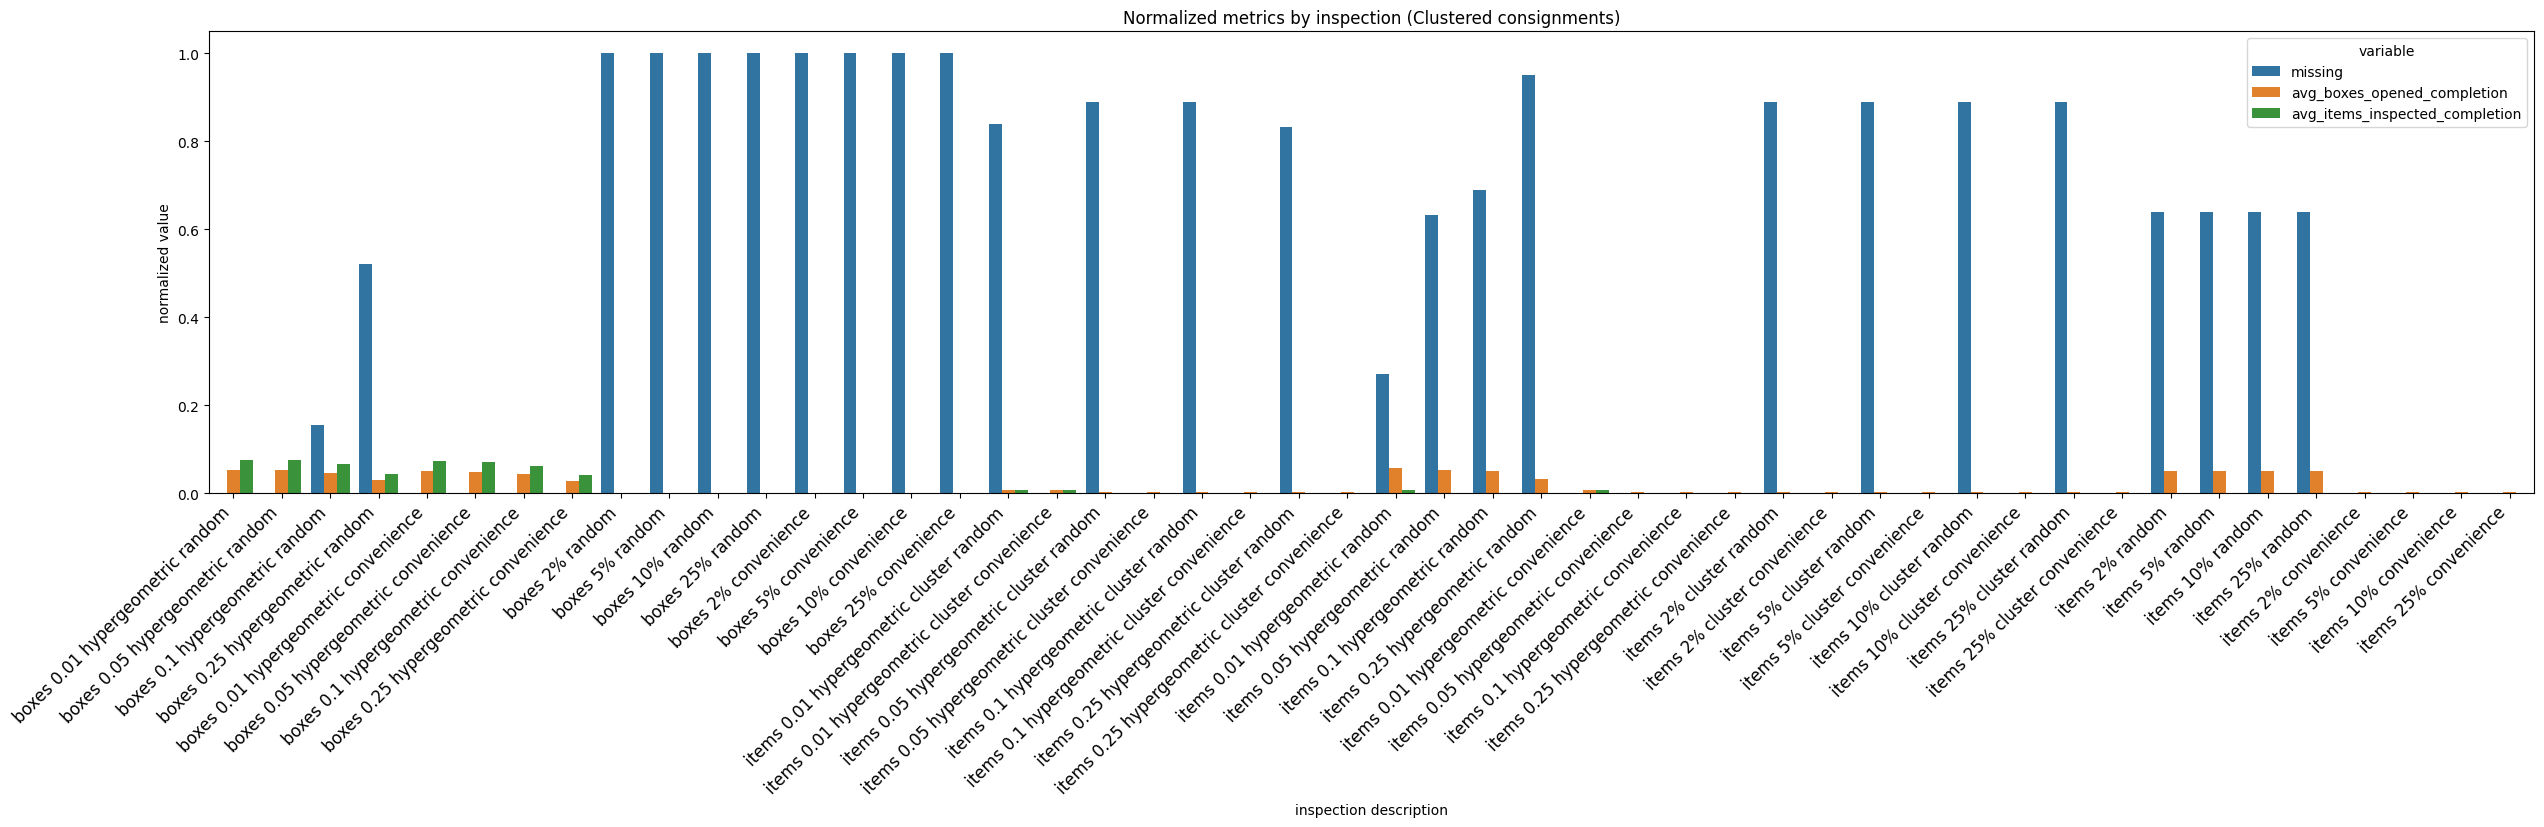

In [42]:
fig, ax1 = plt.subplots(figsize=(30, 6))
chart = sns.barplot(x="inspection_name", y="value", hue="variable",\
                data=df_norm_melted[df_norm_melted.consignment_name.eq("clustered")], ax=ax1)
plt.xticks(
    rotation=45, 
    horizontalalignment='right',
    fontweight='light',
    fontsize='large'  
)
plt.title("Normalized metrics by inspection (Clustered consignments)")
plt.xlabel("inspection description")
plt.ylabel("normalized value")
plt.savefig("metrics_by_inspection_clustered.png", bbox_inches = "tight")

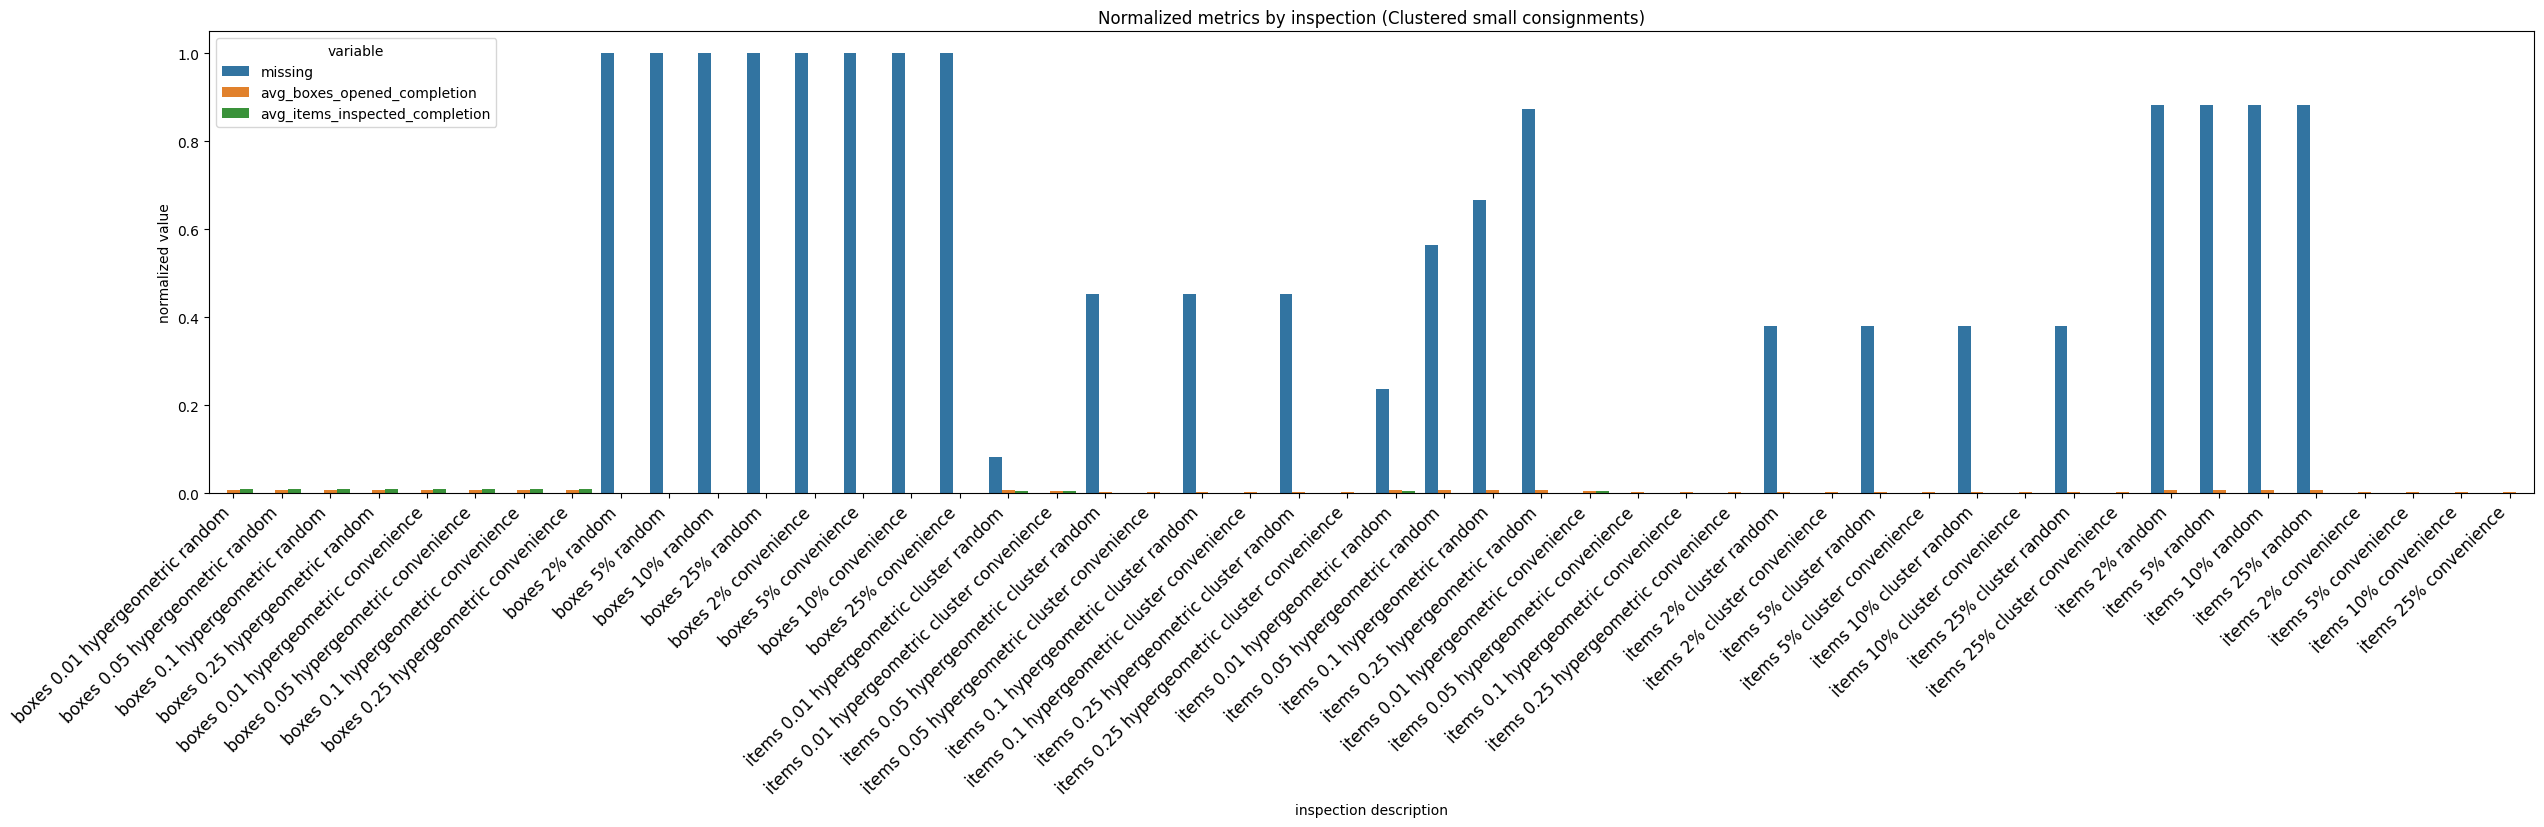

In [43]:
fig, ax1 = plt.subplots(figsize=(30, 6))
chart = sns.barplot(x="inspection_name", y="value", hue="variable",\
                data=df_norm_melted[df_norm_melted.consignment_name.eq("clustered_small")], ax=ax1)
plt.xticks(
    rotation=45, 
    horizontalalignment='right',
    fontweight='light',
    fontsize='large'  
)
plt.title("Normalized metrics by inspection (Clustered small consignments)")
plt.xlabel("inspection description")
plt.ylabel("normalized value")
plt.savefig("metrics_by_inspection_clustered_small.png", bbox_inches = "tight")

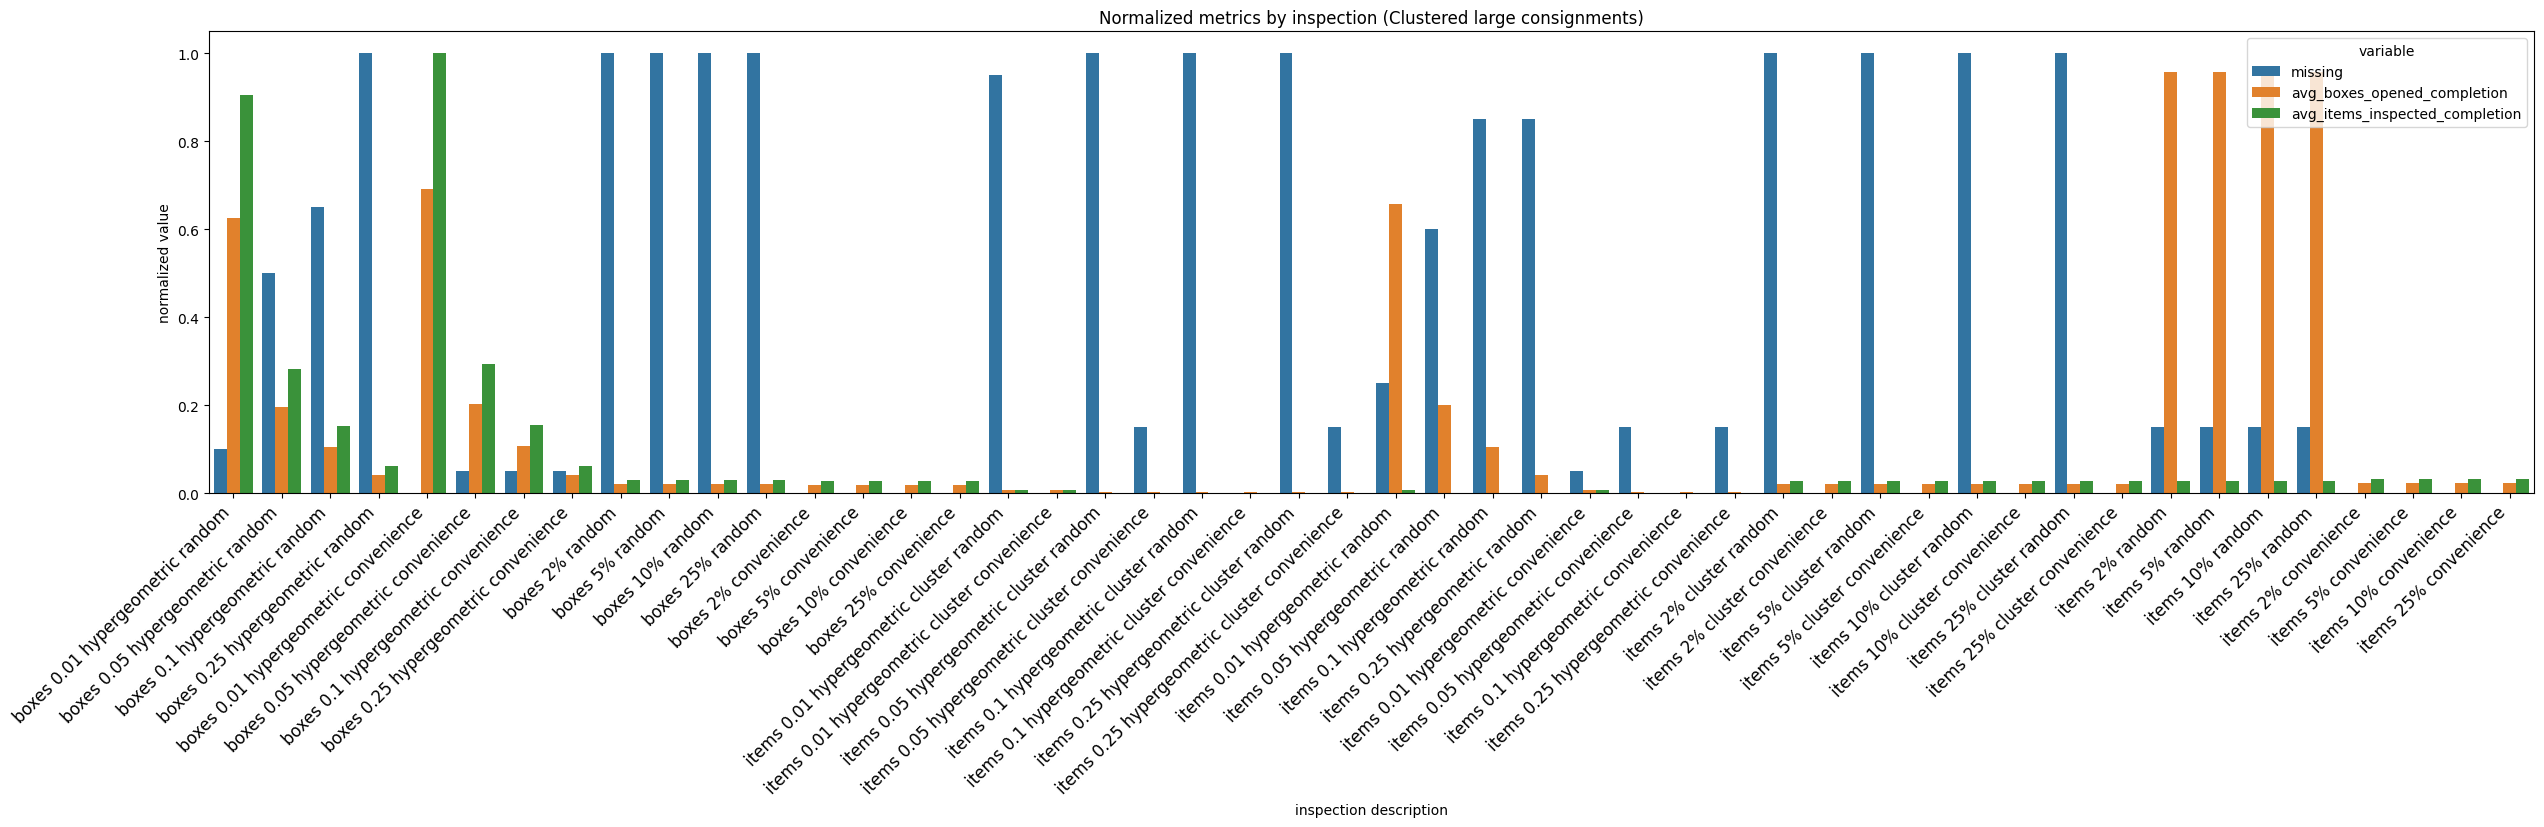

In [44]:
fig, ax1 = plt.subplots(figsize=(30, 6))
chart = sns.barplot(x="inspection_name", y="value", hue="variable",\
                data=df_norm_melted[df_norm_melted.consignment_name.eq("clustered_large")], ax=ax1)
plt.xticks(
    rotation=45, 
    horizontalalignment='right',
    fontweight='light',
    fontsize='large'  
)
plt.title("Normalized metrics by inspection (Clustered large consignments)")
plt.xlabel("inspection description")
plt.ylabel("normalized value")
plt.savefig("metrics_by_inspection_clustered_large.png", bbox_inches = "tight")